# MySuperindo App Reviews - Advanced Preprocessing & Sentiment Analysis
**Kombinasi Week 2 + Week 3: Scraping + Feature Engineering + Advanced Preprocessing**

In [21]:
!pip install google_play_scraper textblob Sastrawi nltk emoji



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from google_play_scraper import app, Sort, reviews
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
from textblob import TextBlob
from pathlib import Path
from nltk.corpus import stopwords
from nltk import word_tokenize, FreqDist
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import pickle
import re
import time
import datetime
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from collections import Counter
import string
import emoji

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15,10)

# Download NLTK data
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ryanf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ryanf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ryanf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
# ⚙️ KONFIGURASI JUMLAH SCRAPING
# Ubah nilai di bawah sesuai kebutuhan untuk mempercepat/memperluas analisis
REVIEW_COUNT = 5000  # Diperkecil dari 50000 untuk kecepatan (ubah sesuai kebutuhan)
# Rekomendasi:
#   - 2000 = Analisis cepat (< 5 menit)
#   - 5000 = Balanced (5-15 menit)
#   - 10000 = Detail (15-30 menit)
#   - 50000 = Komprehensif (> 1 jam)

# Scraping MySuper Indo Reviews
print(f"Mulai mengambil {REVIEW_COUNT} data ulasan MySuperindo...")
app_id = 'id.co.superindo.mysuperindo'

mysuperindo_reviews, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=REVIEW_COUNT
)

df_mysuperindo = pd.DataFrame(mysuperindo_reviews)
print(f"Total ulasan terkumpul: {df_mysuperindo.shape[0]} baris")

# Hapus baris yang content-nya kosong
df_mysuperindo = df_mysuperindo.dropna(subset=['content'])
df_mysuperindo['content'] = df_mysuperindo['content'].astype(str)

# Pilih kolom yang relevan
target_columns = ["content", "score", "thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]
existing_columns = [col for col in target_columns if col in df_mysuperindo.columns]
df_mysuperindo = df_mysuperindo[existing_columns]

print(f"DataFrame shape after cleaning: {df_mysuperindo.shape}")
display(df_mysuperindo.head())


Mulai mengambil 5000 data ulasan MySuperindo...
Total ulasan terkumpul: 5000 baris
DataFrame shape after cleaning: (5000, 7)


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,terlalu sering minta di update,4,0,20.03.000,2026-03-30 18:21:29,None,NaT
1,update teruss...capek deh,3,0,20.03.000,2026-03-29 19:50:15,None,NaT
2,aplikasi udh 2 hri error gada perbaikan,1,0,21.00.000,2026-03-29 10:08:18,None,NaT
3,"tolong dipermudah proses pembatalan pesanan, i...",3,0,21.00.000,2026-03-29 09:24:51,None,NaT
4,saya di Kediri pelayanan lama aplikasi eror ti...,1,0,21.00.000,2026-03-28 20:02:26,None,NaT


In [24]:
df_mysuperindo


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,terlalu sering minta di update,4,0,20.03.000,2026-03-30 18:21:29,None,NaT
1,update teruss...capek deh,3,0,20.03.000,2026-03-29 19:50:15,None,NaT
2,aplikasi udh 2 hri error gada perbaikan,1,0,21.00.000,2026-03-29 10:08:18,None,NaT
3,"tolong dipermudah proses pembatalan pesanan, i...",3,0,21.00.000,2026-03-29 09:24:51,None,NaT
4,saya di Kediri pelayanan lama aplikasi eror ti...,1,0,21.00.000,2026-03-28 20:02:26,None,NaT
...,...,...,...,...,...,...,...
4995,"Sbnrnya bagus, tp kok ni lama g dibuka trs kok...",5,0,2.4.2,2022-02-28 20:25:25,None,NaT
4996,Ok,5,0,2.4.2,2022-02-27 12:55:54,None,NaT
4997,Kurang banyak postingan promonya,4,0,None,2022-02-26 19:17:11,None,NaT
4998,"My Super Indo sy nggak bisa dibuka ya, loading...",1,6,2.4.2,2022-02-26 18:00:34,None,NaT


In [25]:
df_mysuperindo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   content               5000 non-null   object        
 1   score                 5000 non-null   int64         
 2   thumbsUpCount         5000 non-null   int64         
 3   reviewCreatedVersion  4015 non-null   object        
 4   at                    5000 non-null   datetime64[ns]
 5   replyContent          642 non-null    object        
 6   repliedAt             642 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 273.6+ KB


In [26]:
# Feature Engineering - Sentiment Polarity & Subjectivity (from Week 2)
print("Menghitung Sentiment Polarity dan Subjectivity...")

df_mysuperindo['content'] = df_mysuperindo['content'].fillna('')
df_mysuperindo['sentiment_polarity'] = df_mysuperindo['content'].apply(lambda x: TextBlob(x).polarity)
df_mysuperindo['sentiment_subjective'] = df_mysuperindo['content'].apply(lambda x: TextBlob(x).subjectivity)

# Feature Engineering - Word Count Features (from Week 2)
print("Menghitung Word Count Features...")
df_mysuperindo['wordCount'] = [len(review.split()) for review in df_mysuperindo['content']]
df_mysuperindo['uppercaseCharCount'] = [sum(char.isupper() for char in review) for review in df_mysuperindo['content']]
df_mysuperindo['specialCharCount'] = [sum(char in string.punctuation for char in review) for review in df_mysuperindo['content']]

# Sentiment Rating from Score (from Week 2)
df_mysuperindo['sentiment_rating'] = df_mysuperindo['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3 else 'Negative'))

print("Feature Engineering selesai!")
df_mysuperindo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating","wordCount"]]


Menghitung Sentiment Polarity dan Subjectivity...
Menghitung Word Count Features...
Feature Engineering selesai!


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating,wordCount
0,terlalu sering minta di update,4,0.000000,0.000000,Positive,5
1,update teruss...capek deh,3,0.000000,0.000000,Neutral,3
2,aplikasi udh 2 hri error gada perbaikan,1,0.000000,0.000000,Negative,7
3,"tolong dipermudah proses pembatalan pesanan, i...",3,0.000000,0.000000,Neutral,30
4,saya di Kediri pelayanan lama aplikasi eror ti...,1,0.000000,0.000000,Negative,26
...,...,...,...,...,...,...
4995,"Sbnrnya bagus, tp kok ni lama g dibuka trs kok...",5,0.000000,0.000000,Positive,15
4996,Ok,5,0.500000,0.500000,Positive,1
4997,Kurang banyak postingan promonya,4,0.000000,0.000000,Positive,4
4998,"My Super Indo sy nggak bisa dibuka ya, loading...",1,0.333333,0.666667,Negative,22


In [27]:
# Display relevant columns
df_mysuperindo.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,terlalu sering minta di update,4,0,20.03.000,2026-03-30 18:21:29,None,NaT
1,update teruss...capek deh,3,0,20.03.000,2026-03-29 19:50:15,None,NaT
2,aplikasi udh 2 hri error gada perbaikan,1,0,21.00.000,2026-03-29 10:08:18,None,NaT
3,"tolong dipermudah proses pembatalan pesanan, i...",3,0,21.00.000,2026-03-29 09:24:51,None,NaT
4,saya di Kediri pelayanan lama aplikasi eror ti...,1,0,21.00.000,2026-03-28 20:02:26,None,NaT
...,...,...,...,...,...,...,...
4995,"Sbnrnya bagus, tp kok ni lama g dibuka trs kok...",5,0,2.4.2,2022-02-28 20:25:25,None,NaT
4996,Ok,5,0,2.4.2,2022-02-27 12:55:54,None,NaT
4997,Kurang banyak postingan promonya,4,0,None,2022-02-26 19:17:11,None,NaT
4998,"My Super Indo sy nggak bisa dibuka ya, loading...",1,6,2.4.2,2022-02-26 18:00:34,None,NaT


In [28]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd

# Download package NLTK yang dibutuhkan
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# -- A. Persiapan Dictionary & Stopwords --
# 1. Kamus Slang / Kata Alay (Expand Contractions & Spelling Correction)
slang_dict = {
    'yg': 'yang', 'nya': 'nya', 'ga': 'tidak', 'gak': 'tidak', 'utk': 'untuk',
    'bs': 'bisa', 'gk': 'tidak', 'bgt': 'banget', 'jd': 'jadi', 'kalo': 'kalau',
    'tp': 'tapi', 'blm': 'belum', 'udh': 'sudah', 'dgn': 'dengan', 'krn': 'karena',
    'pd': 'pada', 'aja': 'saja', 'sy': 'saya', 'jg': 'juga', 'brg': 'barang',
    'tdk': 'tidak', 'sdh': 'sudah', 'msh': 'masih', 'kok': 'kok', 'lg': 'lagi'
}

# 2. Stopwords Removal
list_stopwords = set(stopwords.words('indonesian'))
custom_stopwords = ['mysuperindo', 'superindo', 'aplikasi', 'app', 'update', 'versi', 'nya', 'sih', 'dong', 'deh', 'ya', 'kan']
list_stopwords.update(custom_stopwords)

# 3. Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# -- B. Fungsi Preprocessing --
def text_preprocessing(text):
    # Cek jika teks kosong / NaN
    if pd.isna(text):
        return []

    # 1. Lowering
    text = str(text).lower()

    # 2. Punctuations Removal (Hanya ambil huruf)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 3. Expand Contractions & Spelling Correction
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    text = ' '.join(words)

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Stopword Removal
    tokens = [word for word in tokens if word not in list_stopwords]

    # 6. Stemming & Lemmatization
    text_stem = ' '.join(tokens)
    text_stem = stemmer.stem(text_stem)

    return text_stem.split()

print("Memulai Preprocessing... (Mohon tunggu, Sastrawi memakan waktu)")

# Menerapkan fungsi ke DataFrame
df_mysuperindo['tokens'] = df_mysuperindo['content'].apply(text_preprocessing)

# Tampilkan hasilnya
df_mysuperindo[['content', 'tokens']].head()


Memulai Preprocessing... (Mohon tunggu, Sastrawi memakan waktu)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ryanf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ryanf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ryanf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,content,tokens
0,terlalu sering minta di update,[]
1,update teruss...capek deh,"[teruss, capek]"
2,aplikasi udh 2 hri error gada perbaikan,"[hri, error, gada, baik]"
3,"tolong dipermudah proses pembatalan pesanan, i...","[tolong, mudah, proses, batal, pesan, salah, a..."
4,saya di Kediri pelayanan lama aplikasi eror ti...,"[diri, layan, eror, terang, kirim, jam, jam, t..."


In [29]:
from collections import Counter

# Ambil semua kata dari kolom tokens
all_words = [word for tokens in df_mysuperindo['tokens'] for word in tokens]
word_freq = Counter(all_words)

COMMON_WORDS_THRESH = 10
RARE_WORDS_THRESH = 1

common_words = set([word for word, count in word_freq.most_common(COMMON_WORDS_THRESH)])
rare_words = set([word for word, count in word_freq.items() if count <= RARE_WORDS_THRESH])

def remove_common_rare(tokens):
    return [w for w in tokens if w not in common_words and w not in rare_words]

# Terapkan ke df_mysuperindo
df_mysuperindo['final_tokens'] = df_mysuperindo['tokens'].apply(remove_common_rare)
df_mysuperindo['clean_text'] = df_mysuperindo['final_tokens'].apply(lambda x: ' '.join(x))

print("Common words removed, rare words removed")
df_mysuperindo[['content', 'clean_text']].head()


Common words removed, rare words removed


,content,clean_text
0,terlalu sering minta di update,
1,update teruss...capek deh,teruss capek
2,aplikasi udh 2 hri error gada perbaikan,hri error gada baik
3,"tolong dipermudah proses pembatalan pesanan, i...",tolong proses batal pesan salah alamat kirim b...
4,saya di Kediri pelayanan lama aplikasi eror ti...,diri eror terang kirim jam jam tunggu hubung k...


In [30]:
from textblob import TextBlob
import pandas as pd

# Fungsi mendapatkan Polarity dan Sentimen
def get_sentiment(text):
    if not text:  # Jika teks kosong setelah di-preprocess
        return 0.0, 'Neutral'

    try:
        # Analisis Polarity dengan Google Translate untuk akurasi lebih baik
        blob = TextBlob(str(text)).translate(from_lang='id', to='en')
        polarity = blob.sentiment.polarity
    except:
        # Fallback jika translation gagal
        polarity = TextBlob(str(text)).sentiment.polarity

    # Penentuan Label Sentimen
    if polarity > 0.05:
        sentiment = 'Positive'
    elif polarity < -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'

    return polarity, sentiment

print("Menghitung Sentiment Polarity dari clean text...")

# Terapkan fungsi ke kolom 'clean_text'
df_mysuperindo[['polarity_clean', 'sentiment_clean']] = df_mysuperindo['clean_text'].apply(lambda x: pd.Series(get_sentiment(x)))

print("Sentiment analysis selesai!")
# Tampilkan hasil
df_mysuperindo[['content', 'clean_text', 'sentiment_polarity', 'polarity_clean', 'sentiment_clean', 'sentiment_rating']].head(10)


Menghitung Sentiment Polarity dari clean text...
Sentiment analysis selesai!


,content,clean_text,sentiment_polarity,polarity_clean,sentiment_clean,sentiment_rating
0,terlalu sering minta di update,,0.0,0.0,Neutral,Positive
1,update teruss...capek deh,teruss capek,0.0,0.0,Neutral,Neutral
2,aplikasi udh 2 hri error gada perbaikan,hri error gada baik,0.0,0.0,Neutral,Negative
3,"tolong dipermudah proses pembatalan pesanan, i...",tolong proses batal pesan salah alamat kirim b...,0.0,0.0,Neutral,Neutral
4,saya di Kediri pelayanan lama aplikasi eror ti...,diri eror terang kirim jam jam tunggu hubung k...,0.0,0.0,Neutral,Negative
5,"belanja mudah, murah dan nyaman",murah nyaman,0.0,0.0,Neutral,Positive
6,belanja d superindo sangat memuaskan. harga ny...,d muas murah jangkau,0.0,0.0,Neutral,Positive
7,tlkubsering update lahh,lahh,0.0,0.0,Neutral,Negative
8,semua produk yg di jual lengkap,produk jual lengkap,0.0,0.0,Neutral,Positive
9,good,good,0.7,0.7,Positive,Positive


Tabel 100 Kata Terbanyak dari MySuperindo Reviews:


,Word,Frequency
0,belanja,899
1,promo,687
2,bagus,478
3,barang,348
4,harga,319
...,...,...
95,jangkau,54
96,gimana,54
97,tampil,53
98,terima,52


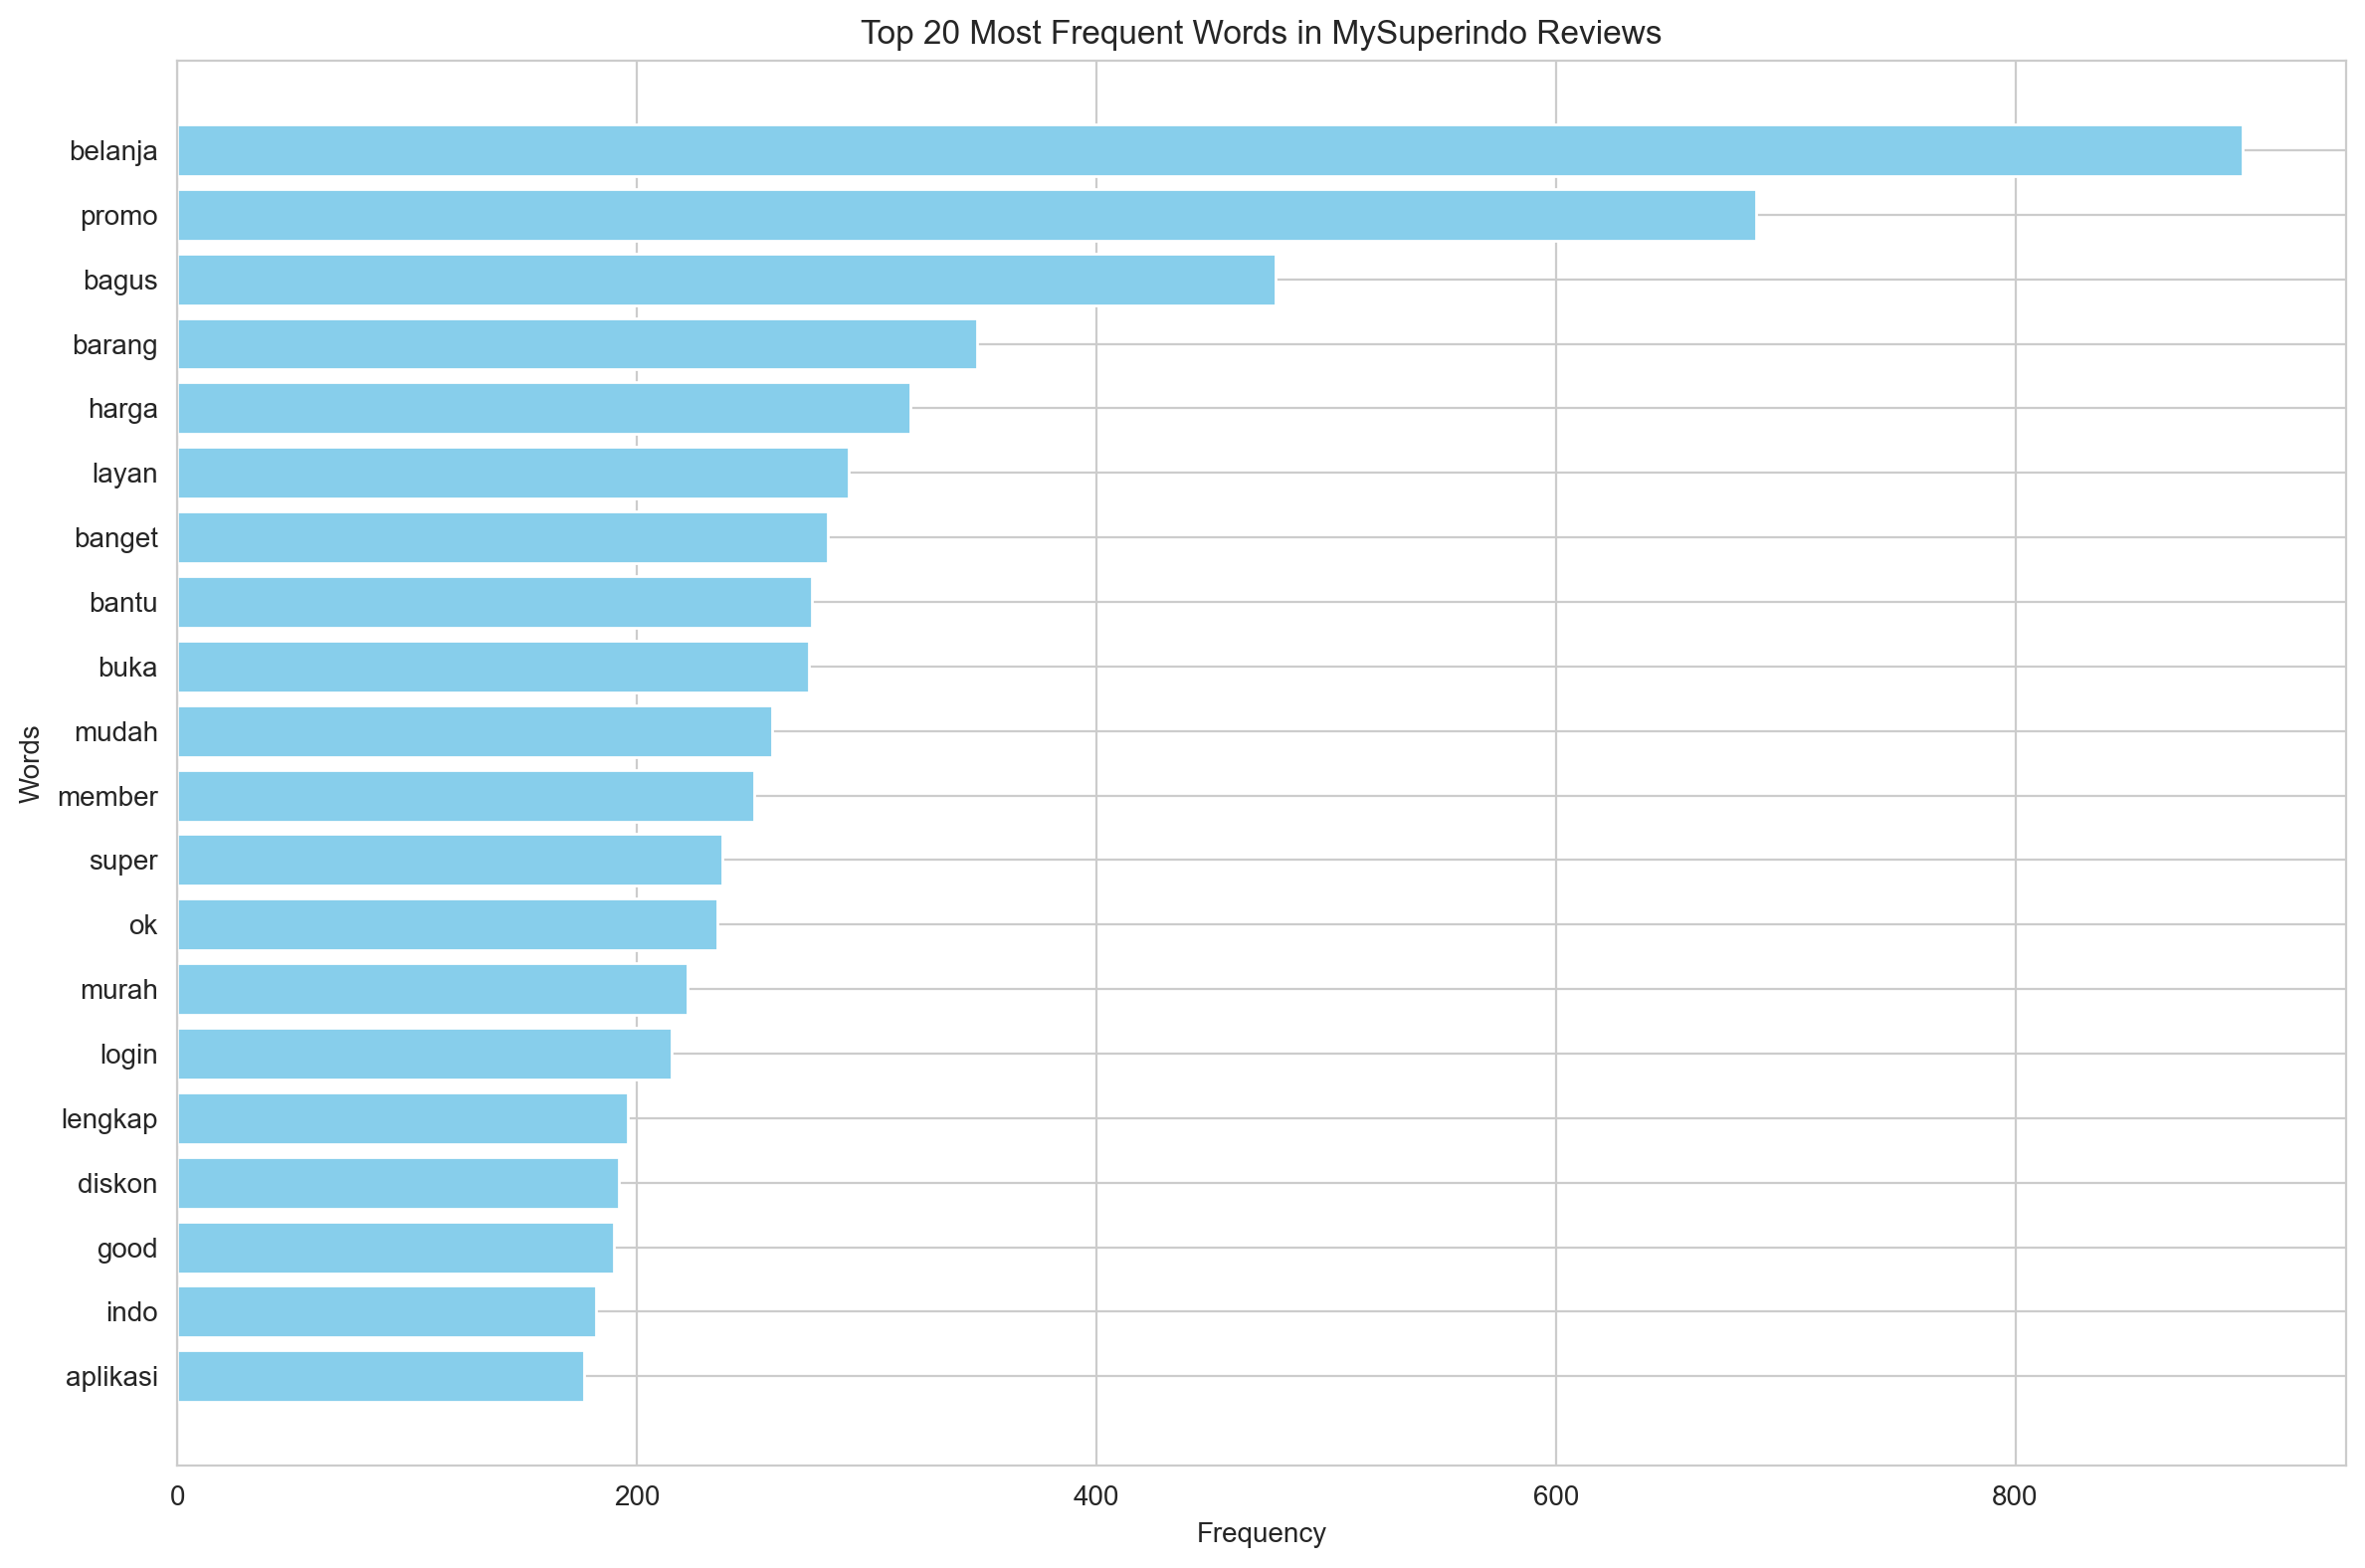

In [31]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from nltk import FreqDist

# 1. Mengambil semua kata dari kolom 'tokens' yang sudah bersih
all_words = [word for tokens in df_mysuperindo['tokens'] for word in tokens]

# 2. Menghitung frekuensi kata
word_counts = Counter(all_words)
common_words_list = word_counts.most_common(100)  # Ambil 100 teratas

# 3. Masukkan ke DataFrame
word_freq_df = pd.DataFrame(common_words_list, columns=['Word', 'Frequency'])

# Tampilkan 100 kata terbanyak dalam bentuk tabel
print("Tabel 100 Kata Terbanyak dari MySuperindo Reviews:")
display(word_freq_df)

# 4. Membuat Visualisasi Grafik (Top 20)
top_20_df = word_freq_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_20_df['Word'][::-1], top_20_df['Frequency'][::-1], color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words in MySuperindo Reviews")
plt.tight_layout()
plt.show()


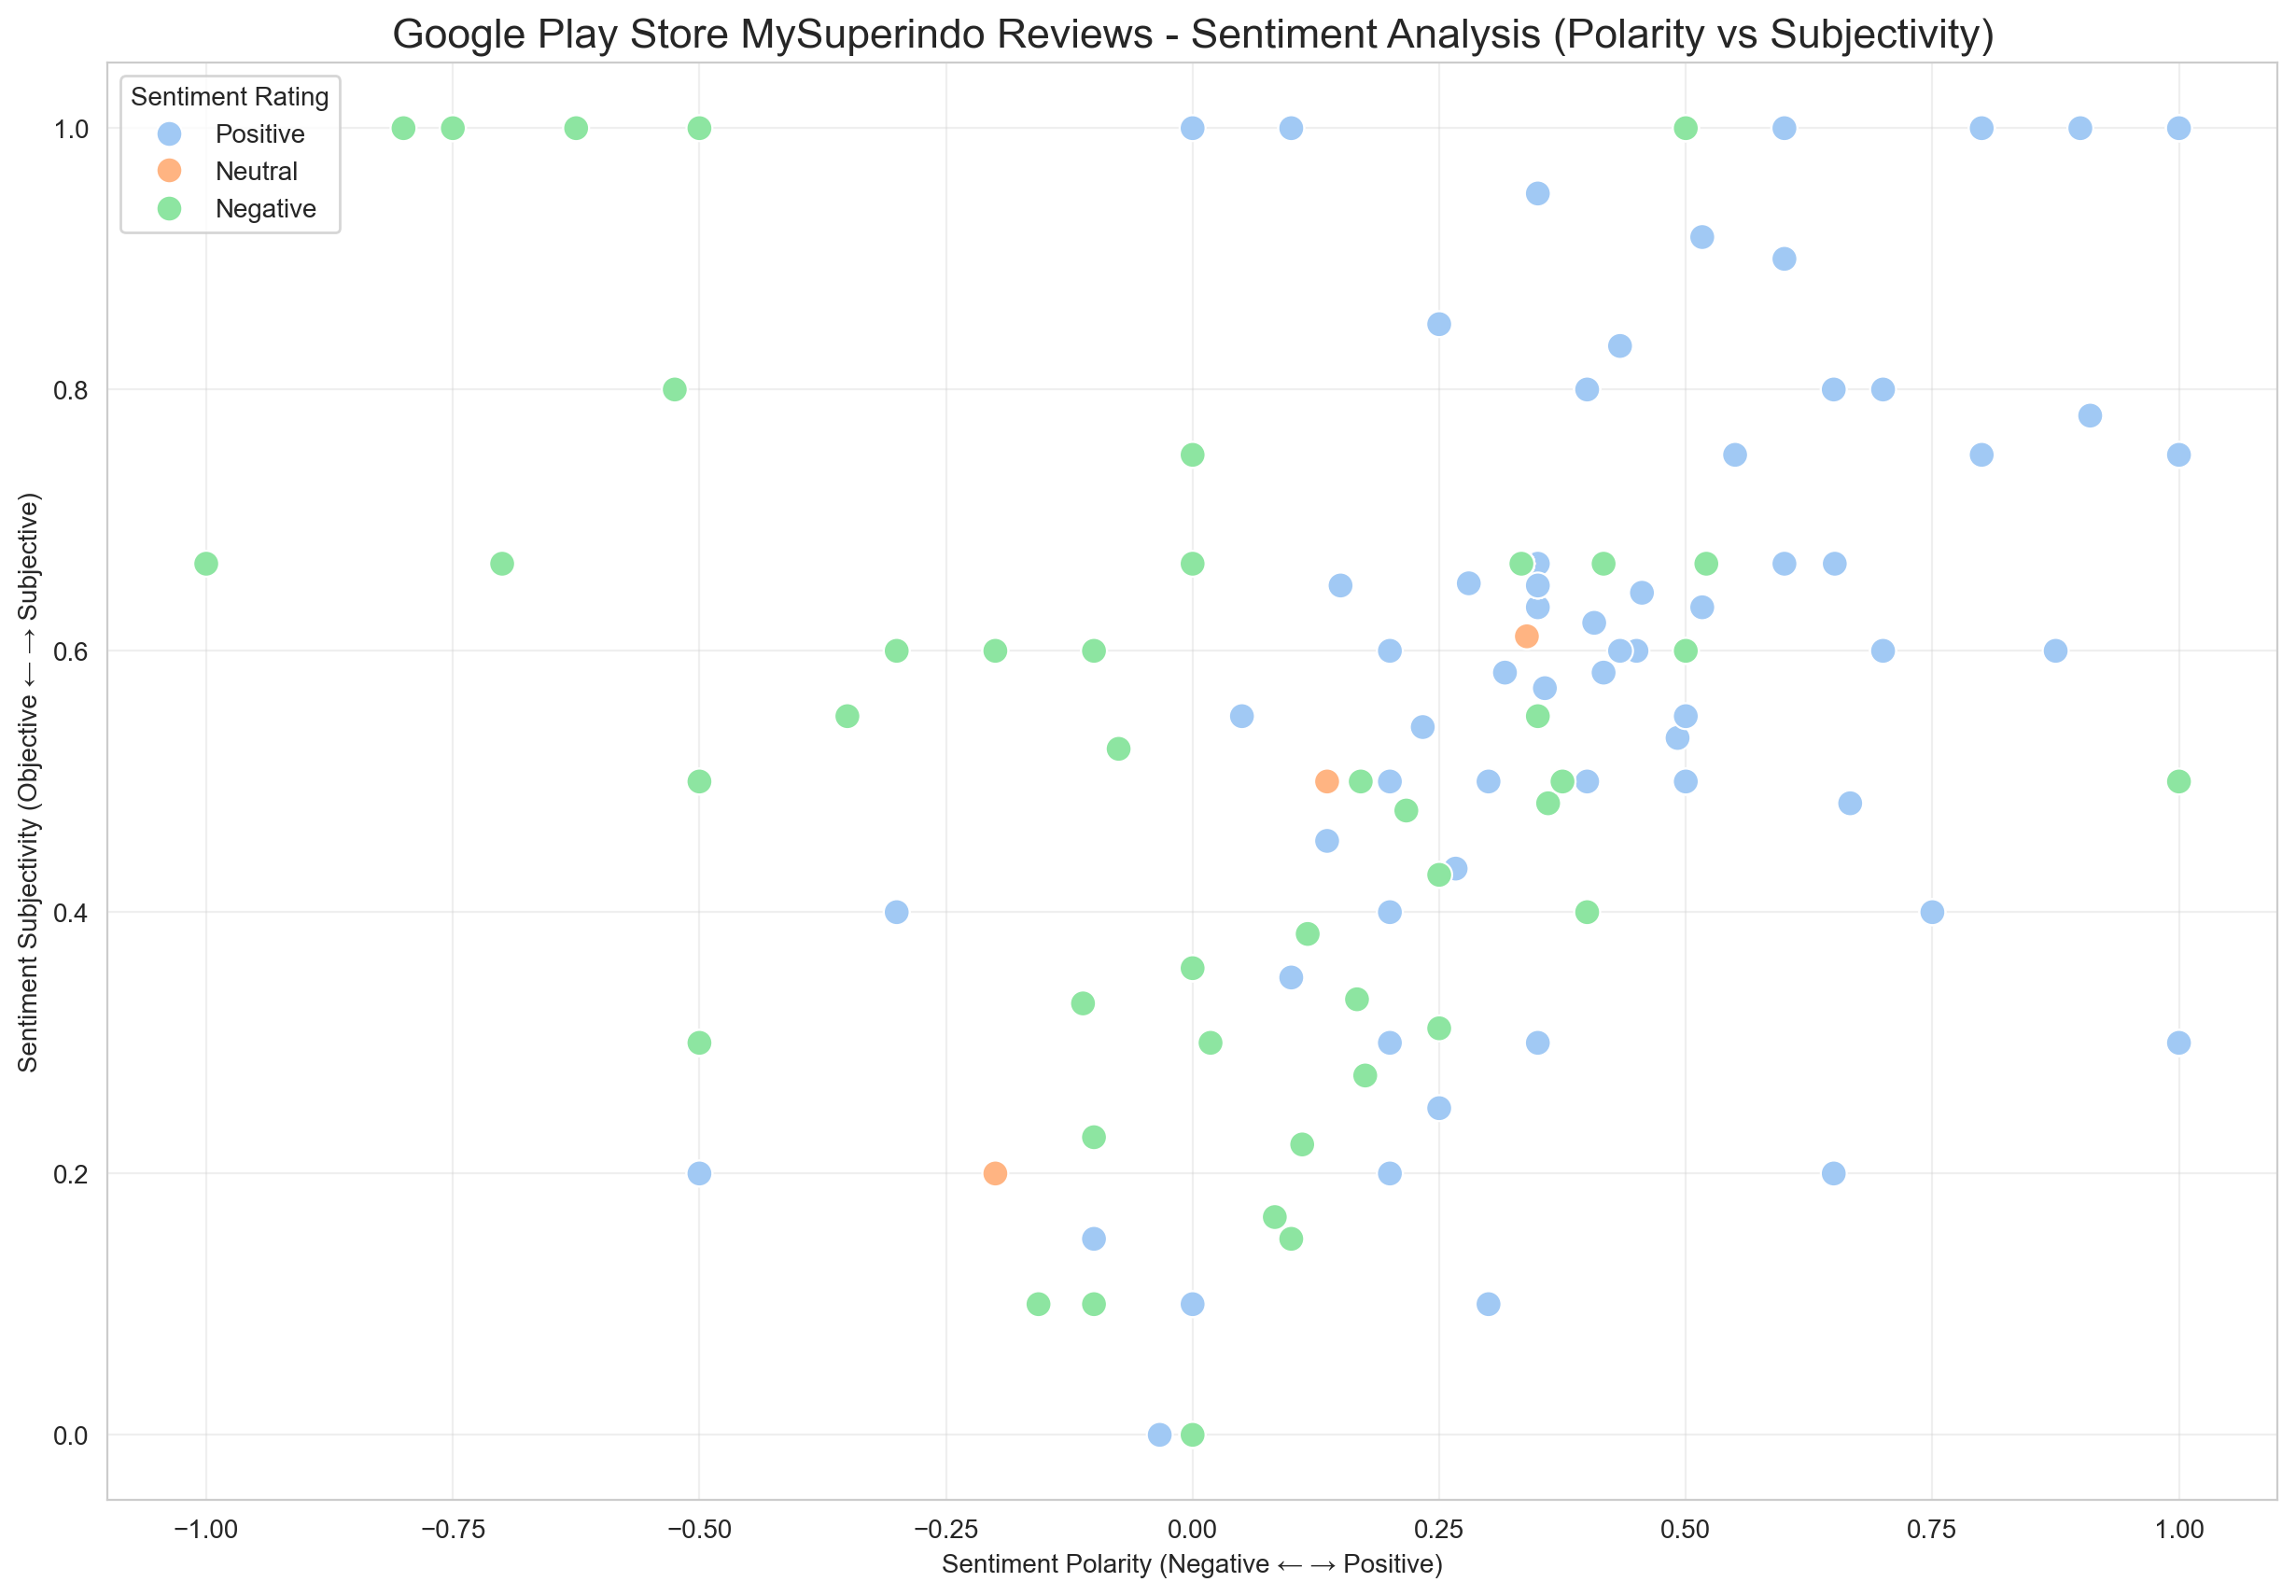


=== Final Data with All Features ===


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating,wordCount,specialCharCount
0,terlalu sering minta di update,4,0.000000,0.000000,Positive,5,0
1,update teruss...capek deh,3,0.000000,0.000000,Neutral,3,3
2,aplikasi udh 2 hri error gada perbaikan,1,0.000000,0.000000,Negative,7,0
3,"tolong dipermudah proses pembatalan pesanan, i...",3,0.000000,0.000000,Neutral,30,2
4,saya di Kediri pelayanan lama aplikasi eror ti...,1,0.000000,0.000000,Negative,26,1
...,...,...,...,...,...,...,...
4995,"Sbnrnya bagus, tp kok ni lama g dibuka trs kok...",5,0.000000,0.000000,Positive,15,8
4996,Ok,5,0.500000,0.500000,Positive,1,0
4997,Kurang banyak postingan promonya,4,0.000000,0.000000,Positive,4,0
4998,"My Super Indo sy nggak bisa dibuka ya, loading...",1,0.333333,0.666667,Negative,22,2


In [32]:
# Scatter Plot Visualization - Polarity vs Subjectivity (from Week 2)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df_mysuperindo,
    x='sentiment_polarity',
    y='sentiment_subjective',
    hue='sentiment_rating',
    edgecolor='white',
    palette="pastel",
    s=100
)
plt.title("Google Play Store MySuperindo Reviews - Sentiment Analysis (Polarity vs Subjectivity)", fontsize=16)
plt.xlabel("Sentiment Polarity (Negative ← → Positive)")
plt.ylabel("Sentiment Subjectivity (Objective ← → Subjective)")
plt.legend(title='Sentiment Rating', loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Display data dengan semua features
print("\n=== Final Data with All Features ===")
df_mysuperindo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating","wordCount","specialCharCount"]]


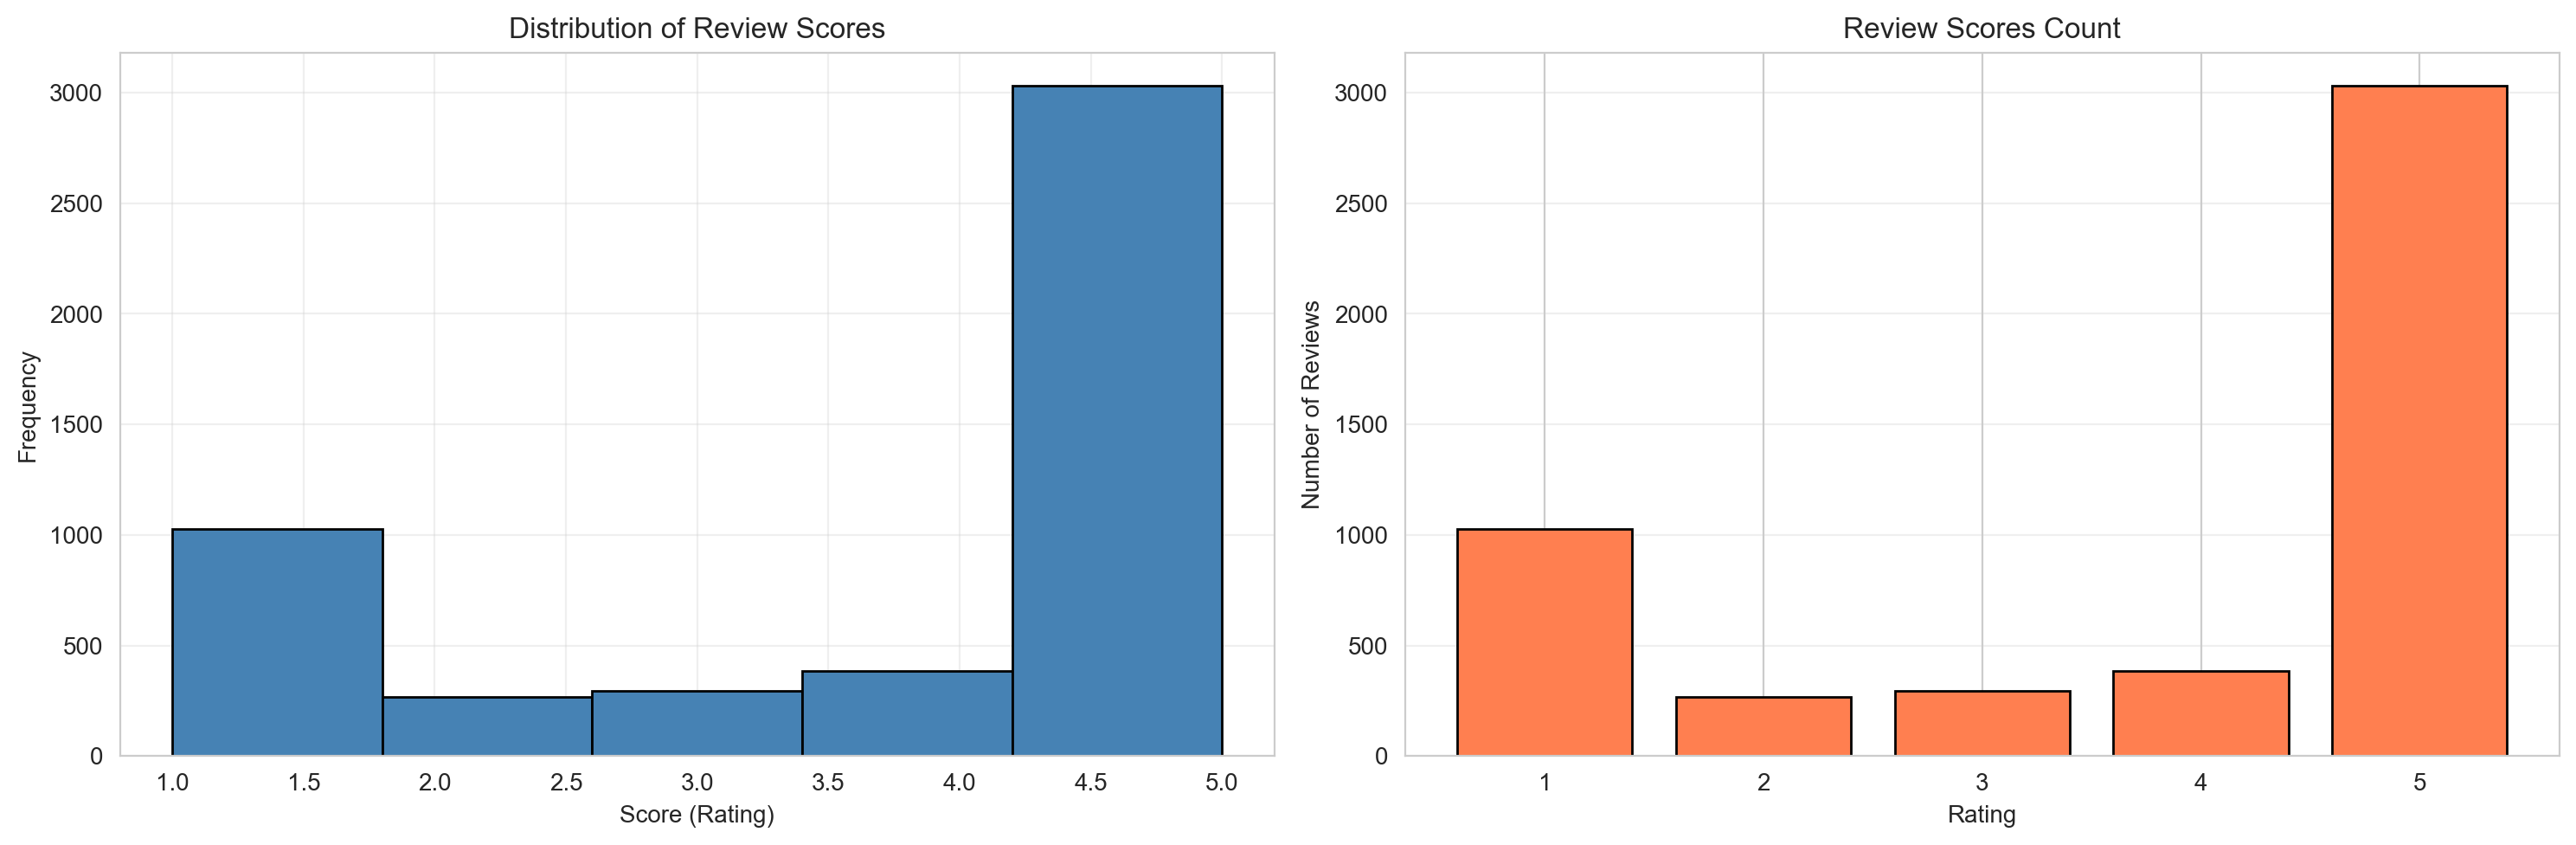


Score Distribution Summary:
score
1    1025
2     267
3     293
4     385
5    3030
Name: count, dtype: int64

Sentiment Rating Distribution:
sentiment_rating
Positive    3415
Negative    1292
Neutral      293
Name: count, dtype: int64


In [33]:
# Score Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_mysuperindo['score'], bins=5, color='steelblue', edgecolor='black')
axes[0].set_title("Distribution of Review Scores")
axes[0].set_xlabel("Score (Rating)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

# Countplot
score_counts = df_mysuperindo['score'].value_counts().sort_index()
axes[1].bar(score_counts.index, score_counts.values, color='coral', edgecolor='black')
axes[1].set_title("Review Scores Count")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nScore Distribution Summary:")
print(df_mysuperindo['score'].value_counts().sort_index())
print(f"\nSentiment Rating Distribution:")
print(df_mysuperindo['sentiment_rating'].value_counts())


## Data Saving & Export

Menyimpan hasil preprocessing ke file CSV untuk Machine Learning dan analisis lebih lanjut.


In [34]:
# Save Before Preprocessing (dengan sentiment features)
filename_before = 'mysuperindo_reviews_before_preprocessing.csv'
df_before_export = df_mysuperindo[['content','score','sentiment_polarity', 'sentiment_subjective','sentiment_rating','wordCount','uppercaseCharCount','specialCharCount']]
df_before_export.to_csv(filename_before, index=False)
print(f"✓ File berhasil disimpan: {filename_before}")

# Save After Preprocessing (clean text)
filename_after = 'mysuperindo_reviews_after_preprocessing.csv'
df_after_export = df_mysuperindo[['content','score','sentiment_polarity', 'sentiment_subjective','sentiment_rating','tokens','clean_text','polarity_clean','sentiment_clean']]
df_after_export.to_csv(filename_after, index=False)
print(f"✓ File berhasil disimpan: {filename_after}")

# Save Complete Dataset
filename_complete = 'mysuperindo_reviews_complete.csv'
df_mysuperindo.to_csv(filename_complete, index=False)
print(f"✓ File berhasil disimpan: {filename_complete}")

print(f"\nTotal data exported: {len(df_mysuperindo)} reviews")


✓ File berhasil disimpan: mysuperindo_reviews_before_preprocessing.csv
✓ File berhasil disimpan: mysuperindo_reviews_after_preprocessing.csv
✓ File berhasil disimpan: mysuperindo_reviews_complete.csv

Total data exported: 5000 reviews


In [35]:
# Final Summary & Data Preview
print("="*80)
print("SUMMARY: MySuperindo App Reviews - Advanced Preprocessing & Sentiment Analysis")
print("="*80)
print(f"\n📊 Dataset Statistics:")
print(f"   Total Reviews: {len(df_mysuperindo)}")
print(f"   Date Range: {df_mysuperindo['at'].min()} to {df_mysuperindo['at'].max()}")
print(f"\n⭐ Score Distribution:")
for score in sorted(df_mysuperindo['score'].unique()):
    count = (df_mysuperindo['score'] == score).sum()
    pct = (count / len(df_mysuperindo)) * 100
    print(f"   {int(score)} Stars: {count} ({pct:.1f}%)")

print(f"\n💭 Sentiment Rating Distribution:")
for rating in df_mysuperindo['sentiment_rating'].unique():
    count = (df_mysuperindo['sentiment_rating'] == rating).sum()
    pct = (count / len(df_mysuperindo)) * 100
    print(f"   {rating}: {count} ({pct:.1f}%)")

print(f"\n📈 Polarity Statistics:")
print(f"   Mean: {df_mysuperindo['sentiment_polarity'].mean():.4f}")
print(f"   Min: {df_mysuperindo['sentiment_polarity'].min():.4f}")
print(f"   Max: {df_mysuperindo['sentiment_polarity'].max():.4f}")

print(f"\n📝 Text Statistics:")
print(f"   Average Word Count: {df_mysuperindo['wordCount'].mean():.1f}")
print(f"   Max Word Count: {df_mysuperindo['wordCount'].max()}")
print(f"   Min Word Count: {df_mysuperindo['wordCount'].min()}")

print("\n" + "="*80)
print("✅ PREPROCESSING COMPLETED SUCCESSFULLY!")
print("="*80)


SUMMARY: MySuperindo App Reviews - Advanced Preprocessing & Sentiment Analysis

📊 Dataset Statistics:
   Total Reviews: 5000
   Date Range: 2022-02-26 07:39:28 to 2026-03-30 18:21:29

⭐ Score Distribution:
   1 Stars: 1025 (20.5%)
   2 Stars: 267 (5.3%)
   3 Stars: 293 (5.9%)
   4 Stars: 385 (7.7%)
   5 Stars: 3030 (60.6%)

💭 Sentiment Rating Distribution:
   Positive: 3415 (68.3%)
   Neutral: 293 (5.9%)
   Negative: 1292 (25.8%)

📈 Polarity Statistics:
   Mean: 0.0807
   Min: -1.0000
   Max: 1.0000

📝 Text Statistics:
   Average Word Count: 10.0
   Max Word Count: 95
   Min Word Count: 1

✅ PREPROCESSING COMPLETED SUCCESSFULLY!


## Bag of Words (BoW) Analysis

Menganalisis ulasan menggunakan metode Bag of Words untuk mengubah teks menjadi representasi numerik berdasarkan frekuensi kata.

IMPLEMENTASI BAG OF WORDS (BoW)

Bag of Words Matrix Shape: (5000, 100)
Jumlah dokumen (reviews): 5000
Jumlah fitur (unique words): 100

Bag of Words DataFrame Head:


,akun,ambil,apk,aplikasi,baik,baru,bayar,beli,bikin,buah,...,susah,tampil,tarik,tau,terima,toko,tolong,udah,ulang,upgrade
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



STATISTIK BAG OF WORDS

Top 30 Kata Paling Sering Muncul (dengan frekuensi):


member      251
super       237
ok          235
murah       222
login       215
lengkap     196
diskon      192
good        190
indo        182
aplikasi    177
masuk       170
susah       163
nyaman      162
email       157
online      156
daftar      156
udah        140
ramah       137
pas         137
mantap      135
promonya    134
tolong      131
suka        130
produk      126
baik        123
bikin       121
pakai       114
butuh       114
beli        113
rumah       112
dtype: int64

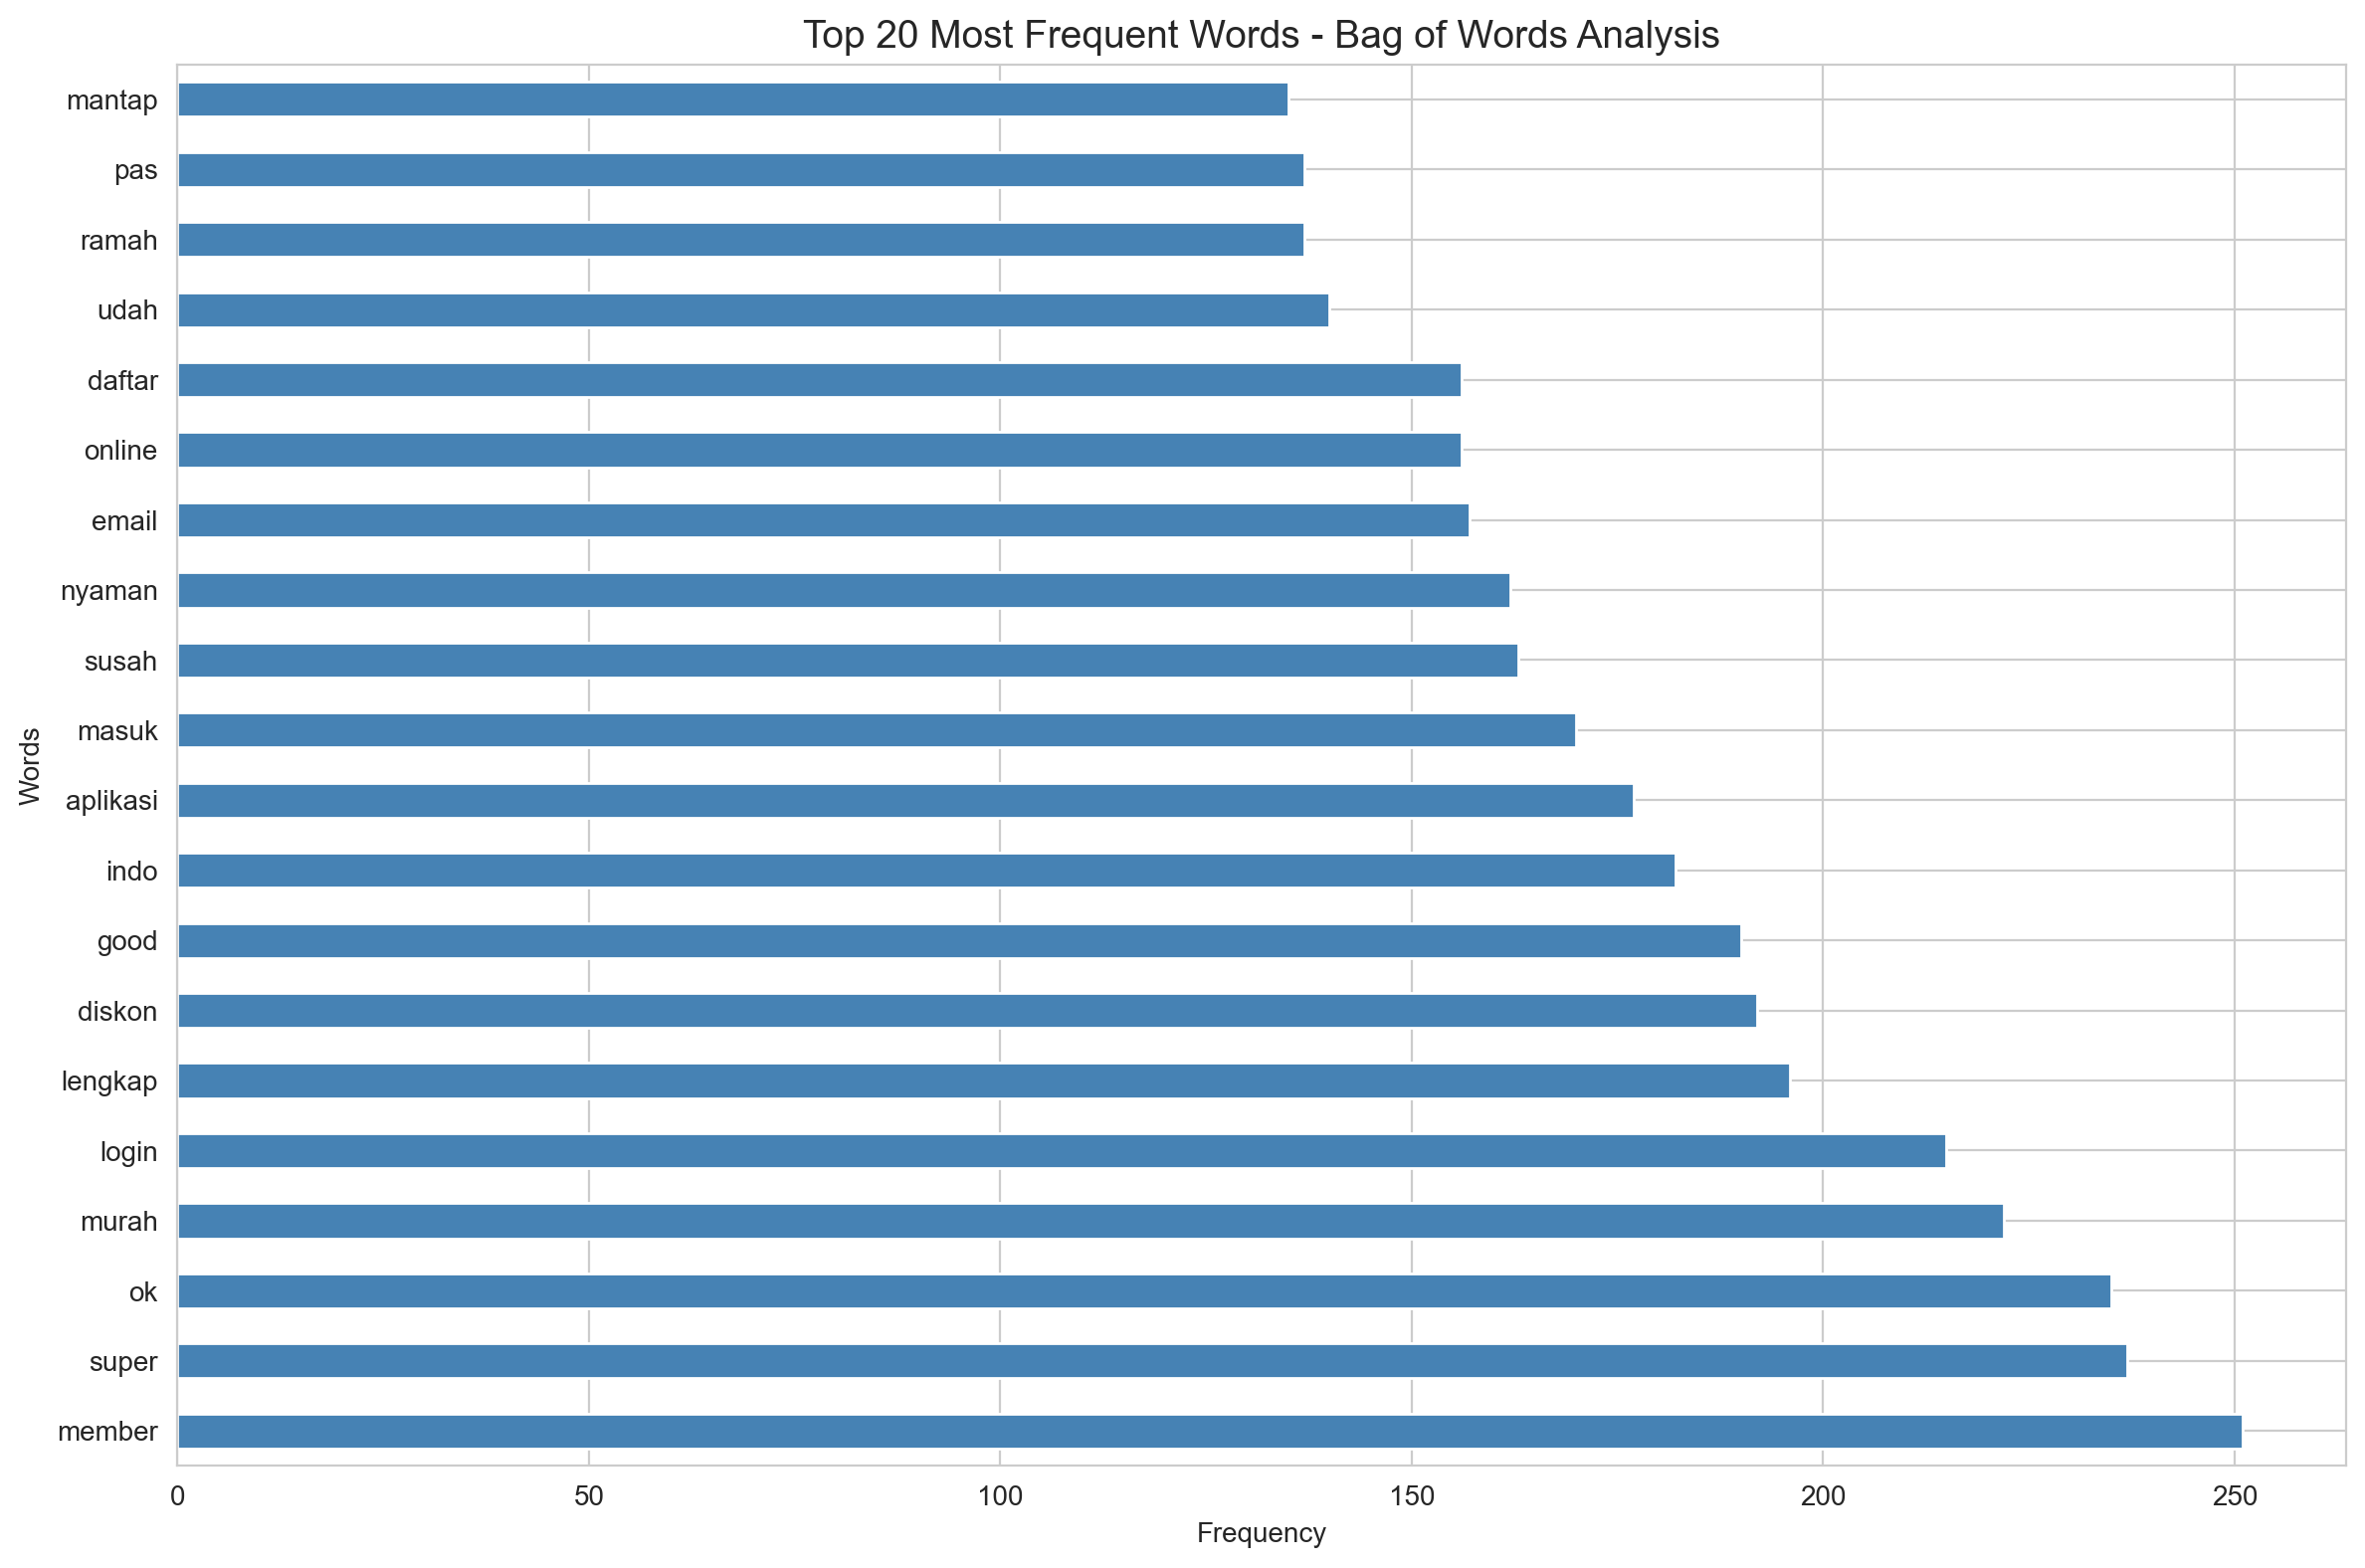

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi CountVectorizer untuk Bag of Words
print("="*80)
print("IMPLEMENTASI BAG OF WORDS (BoW)")
print("="*80)

# Menggunakan clean_text untuk BoW analysis
vectorizer = CountVectorizer(
    max_features=100,  # Ambil 100 fitur/kata teratas
    min_df=5,           # Kata harus muncul minimal 5 dokumen
    max_df=0.8          # Kata tidak boleh muncul di lebih dari 80% dokumen
)

# Fit dan transform teks
bow_matrix = vectorizer.fit_transform(df_mysuperindo['clean_text'])
print(f"\nBag of Words Matrix Shape: {bow_matrix.shape}")
print(f"Jumlah dokumen (reviews): {bow_matrix.shape[0]}")
print(f"Jumlah fitur (unique words): {bow_matrix.shape[1]}")

# 2. Konversi ke DataFrame untuk analisis lebih mudah
feature_names = vectorizer.get_feature_names_out()
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=feature_names)

print(f"\nBag of Words DataFrame Head:")
display(bow_df.head())

# 3. Analisis frekuensi kata dalam Bag of Words
print("\n" + "="*80)
print("STATISTIK BAG OF WORDS")
print("="*80)

# Total kemunculan setiap kata
word_frequencies = bow_df.sum(axis=0).sort_values(ascending=False)
print(f"\nTop 30 Kata Paling Sering Muncul (dengan frekuensi):")
display(word_frequencies.head(30))

# Visualisasi Top 20 kata
fig, ax = plt.subplots(figsize=(12, 8))
word_frequencies.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel("Frequency")
ax.set_ylabel("Words")
ax.set_title("Top 20 Most Frequent Words - Bag of Words Analysis", fontsize=14)
plt.tight_layout()
plt.show()


BAG OF WORDS PER SENTIMENT RATING

Negative Reviews - Top 10 Words:


,Word,Frequency
0,login,187
1,email,137
2,daftar,131
3,masuk,124
4,susah,119
5,member,111
6,udah,108
7,aplikasi,102
8,online,98
9,bikin,90



Neutral Reviews - Top 10 Words:


,Word,Frequency
0,member,24
1,susah,23
2,katalog,20
3,baru,19
4,tolong,18
5,aplikasi,18
6,pas,16
7,klo,16
8,cari,16
9,baik,16



Positive Reviews - Top 10 Words:


,Word,Frequency
0,ok,219
1,murah,210
2,super,193
3,good,187
4,lengkap,174
5,diskon,166
6,nyaman,148
7,indo,143
8,mantap,133
9,ramah,127


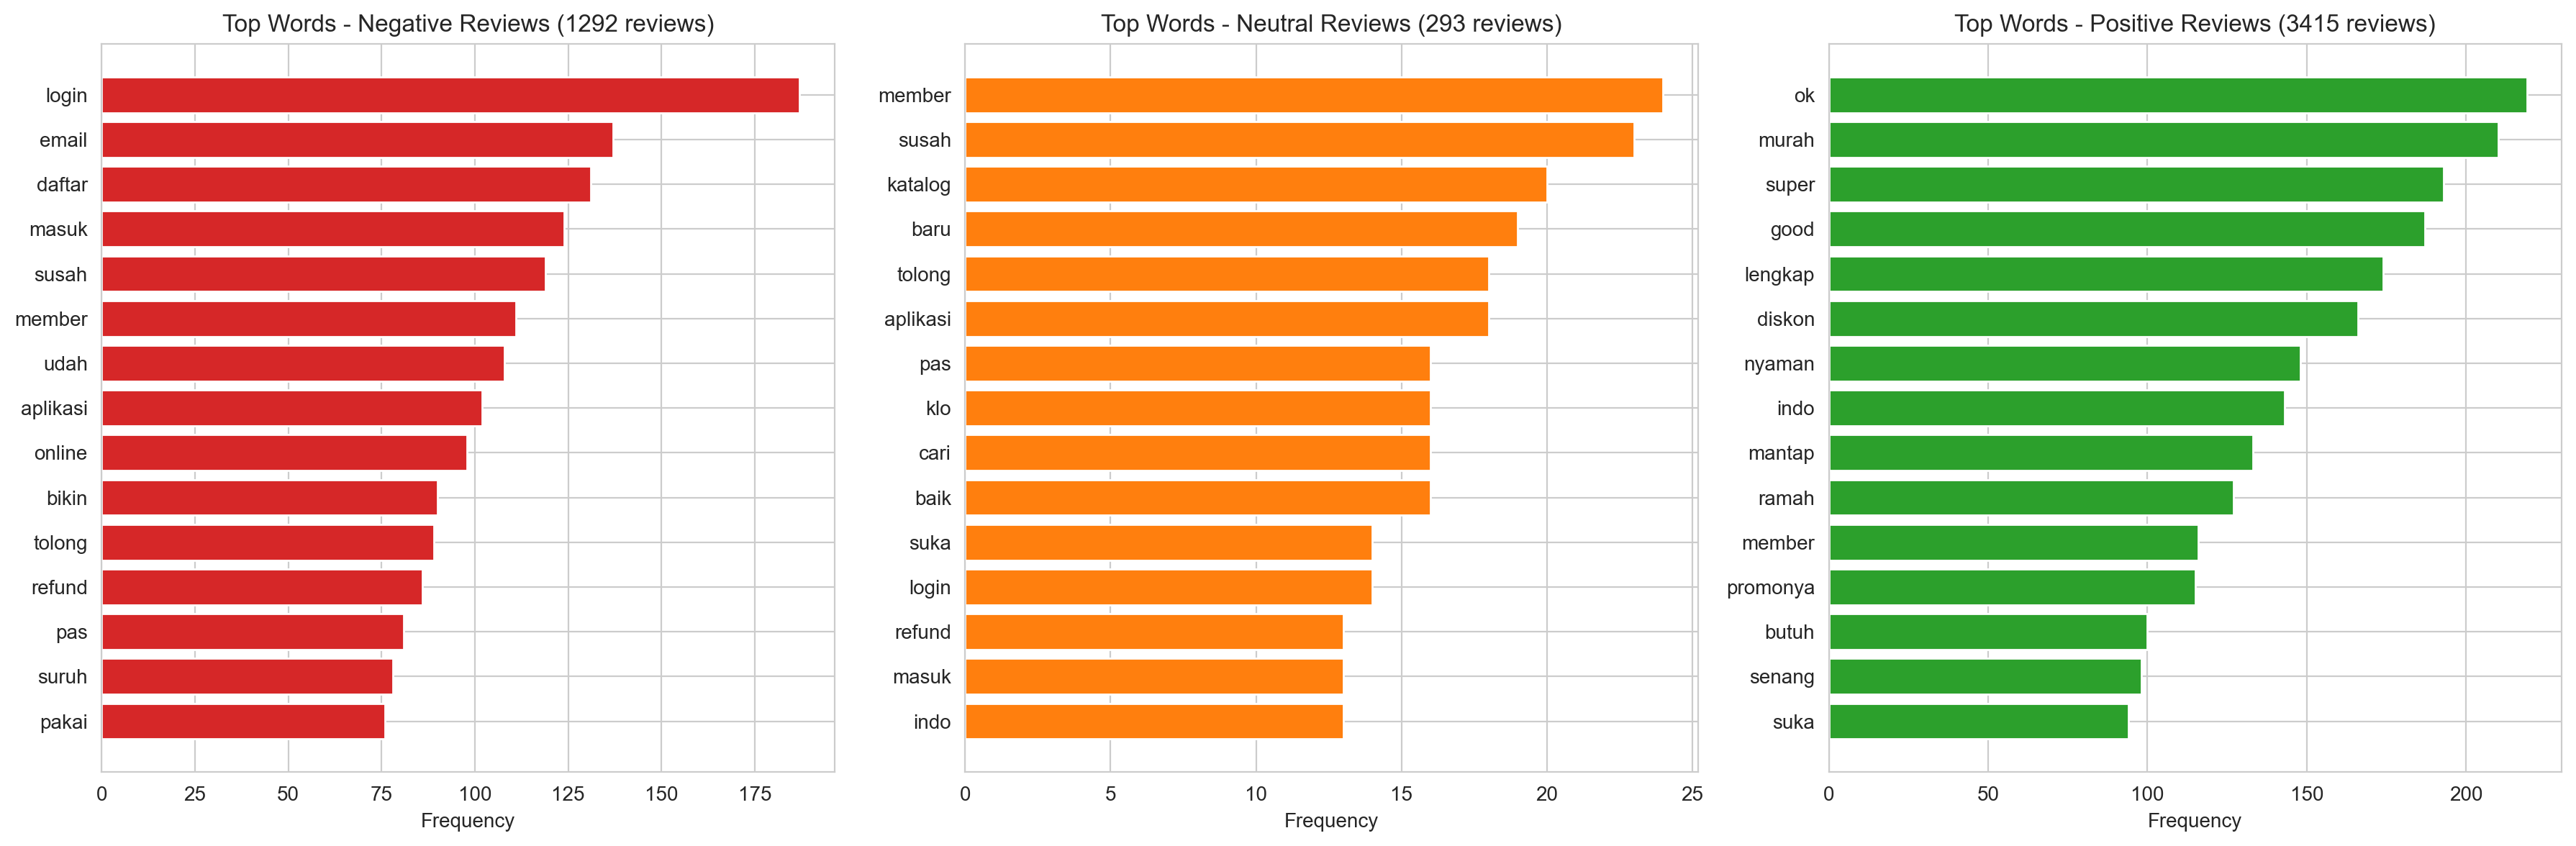

In [37]:
# 4. Bag of Words Analysis per Sentiment Rating
print("="*80)
print("BAG OF WORDS PER SENTIMENT RATING")
print("="*80)

sentiments = df_mysuperindo['sentiment_rating'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment in enumerate(sorted(sentiments)):
    # Filter data berdasarkan sentiment
    sentiment_texts = df_mysuperindo[df_mysuperindo['sentiment_rating'] == sentiment]['clean_text']
    
    # Buat BoW untuk sentiment spesifik
    vectorizer_sentiment = CountVectorizer(max_features=15, min_df=2)
    bow_sentiment = vectorizer_sentiment.fit_transform(sentiment_texts)
    feature_names_sentiment = vectorizer_sentiment.get_feature_names_out()
    
    # Hitung frekuensi
    word_freq_sentiment = bow_sentiment.sum(axis=0).A1
    
    # Urutkan
    sorted_indices = np.argsort(word_freq_sentiment)[::-1]
    sorted_words = feature_names_sentiment[sorted_indices]
    sorted_freqs = word_freq_sentiment[sorted_indices]
    
    # Plot
    axes[idx].barh(sorted_words, sorted_freqs, color=['#d62728' if sentiment == 'Negative' else '#2ca02c' if sentiment == 'Positive' else '#ff7f0e'][0])
    axes[idx].set_xlabel("Frequency")
    axes[idx].set_title(f"Top Words - {sentiment} Reviews ({len(sentiment_texts)} reviews)")
    axes[idx].invert_yaxis()
    
    print(f"\n{sentiment} Reviews - Top 10 Words:")
    sentiment_word_freq = pd.DataFrame({
        'Word': sorted_words,
        'Frequency': sorted_freqs
    }).head(10)
    display(sentiment_word_freq)

plt.tight_layout()
plt.show()


BAG OF WORDS PER STAR RATING

1 Stars - Top 10 Words (1025 reviews):


,Word,Frequency
0,login,156
1,email,122
2,daftar,105
3,masuk,95
4,susah,94
5,udah,90
6,member,86
7,bikin,77
8,refund,75
9,aplikasi,74



2 Stars - Top 10 Words (267 reviews):


,Word,Frequency
0,login,31
1,masuk,29
2,aplikasi,28
3,online,27
4,daftar,26
5,susah,25
6,member,25
7,baru,24
8,tolong,19
9,lot,19



3 Stars - Top 10 Words (293 reviews):


...


4 Stars - Top 10 Words (385 reviews):


,Word,Frequency
0,ok,24
1,suka,17
2,lumayan,17
3,toko,14
4,lengkap,14
5,pas,13
6,masuk,13
7,tolong,12
8,online,12
9,katalog,12



5 Stars - Top 10 Words (3030 reviews):


,Word,Frequency
0,murah,202
1,ok,195
2,super,183
3,good,176
4,lengkap,160
5,diskon,155
6,nyaman,139
7,indo,136
8,mantap,124
9,ramah,117


C:\Users\ryanf\AppData\Local\Temp\ipykernel_30516\2827614358.py:46: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ryanf\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


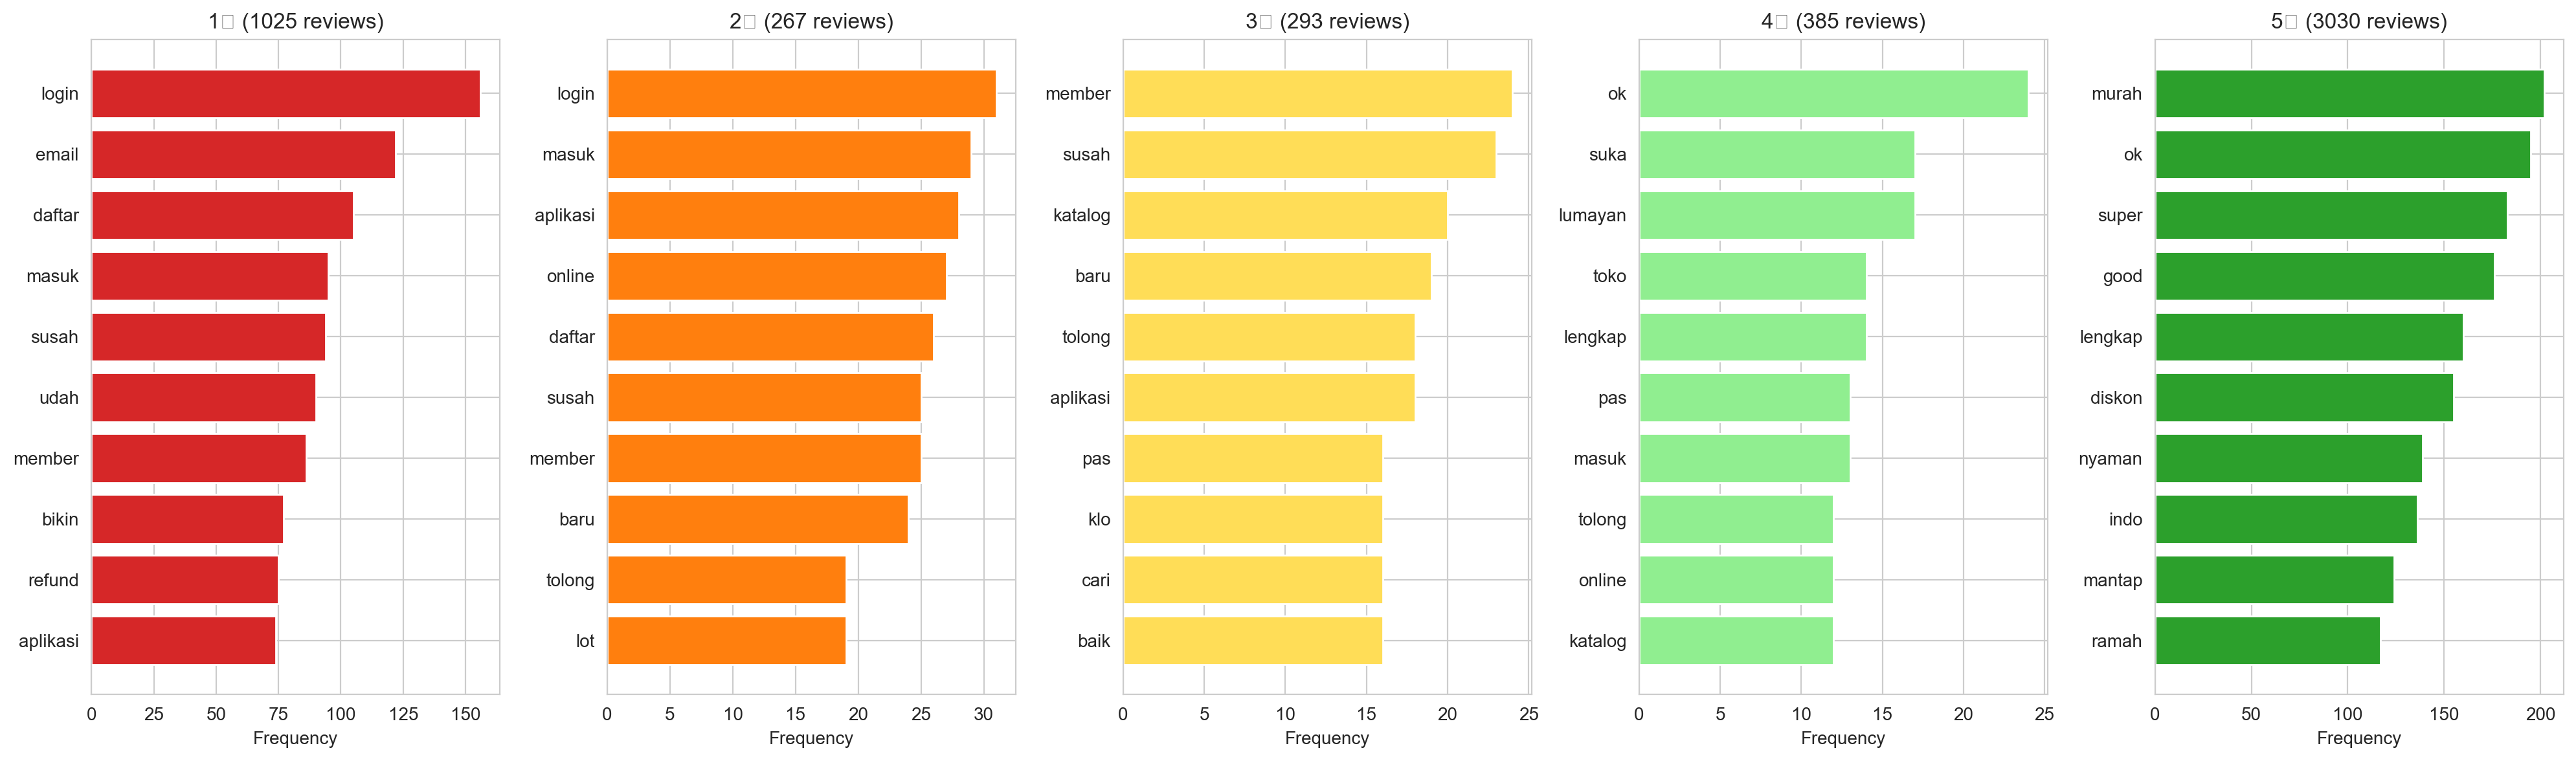

In [38]:
# 5. Analisis BoW dengan Star Rating (1-5)
print("="*80)
print("BAG OF WORDS PER STAR RATING")
print("="*80)

ratings = sorted(df_mysuperindo['score'].unique())
top_n = 10

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

rating_top_words = {}

for rating_idx, rating in enumerate(ratings):
    # Filter data berdasarkan rating
    rating_texts = df_mysuperindo[df_mysuperindo['score'] == rating]['clean_text']
    
    # Buat BoW untuk rating spesifik
    vectorizer_rating = CountVectorizer(max_features=top_n, min_df=1)
    bow_rating = vectorizer_rating.fit_transform(rating_texts)
    feature_names_rating = vectorizer_rating.get_feature_names_out()
    
    # Hitung frekuensi
    word_freq_rating = bow_rating.sum(axis=0).A1
    
    # Urutkan
    sorted_indices = np.argsort(word_freq_rating)[::-1]
    sorted_words = feature_names_rating[sorted_indices]
    sorted_freqs = word_freq_rating[sorted_indices]
    
    rating_top_words[rating] = list(zip(sorted_words, sorted_freqs))
    
    # Plot
    color_map = {1: '#d62728', 2: '#ff7f0e', 3: '#ffdd57', 4: '#90ee90', 5: '#2ca02c'}
    axes[rating_idx].barh(sorted_words, sorted_freqs, color=color_map[rating])
    axes[rating_idx].set_xlabel("Frequency")
    axes[rating_idx].set_title(f"{int(rating)}⭐ ({len(rating_texts)} reviews)")
    axes[rating_idx].invert_yaxis()
    
    print(f"\n{int(rating)} Stars - Top {top_n} Words ({len(rating_texts)} reviews):")
    rating_word_freq = pd.DataFrame({
        'Word': sorted_words,
        'Frequency': sorted_freqs
    })
    display(rating_word_freq)

plt.tight_layout()
plt.show()


HEATMAP BAG OF WORDS


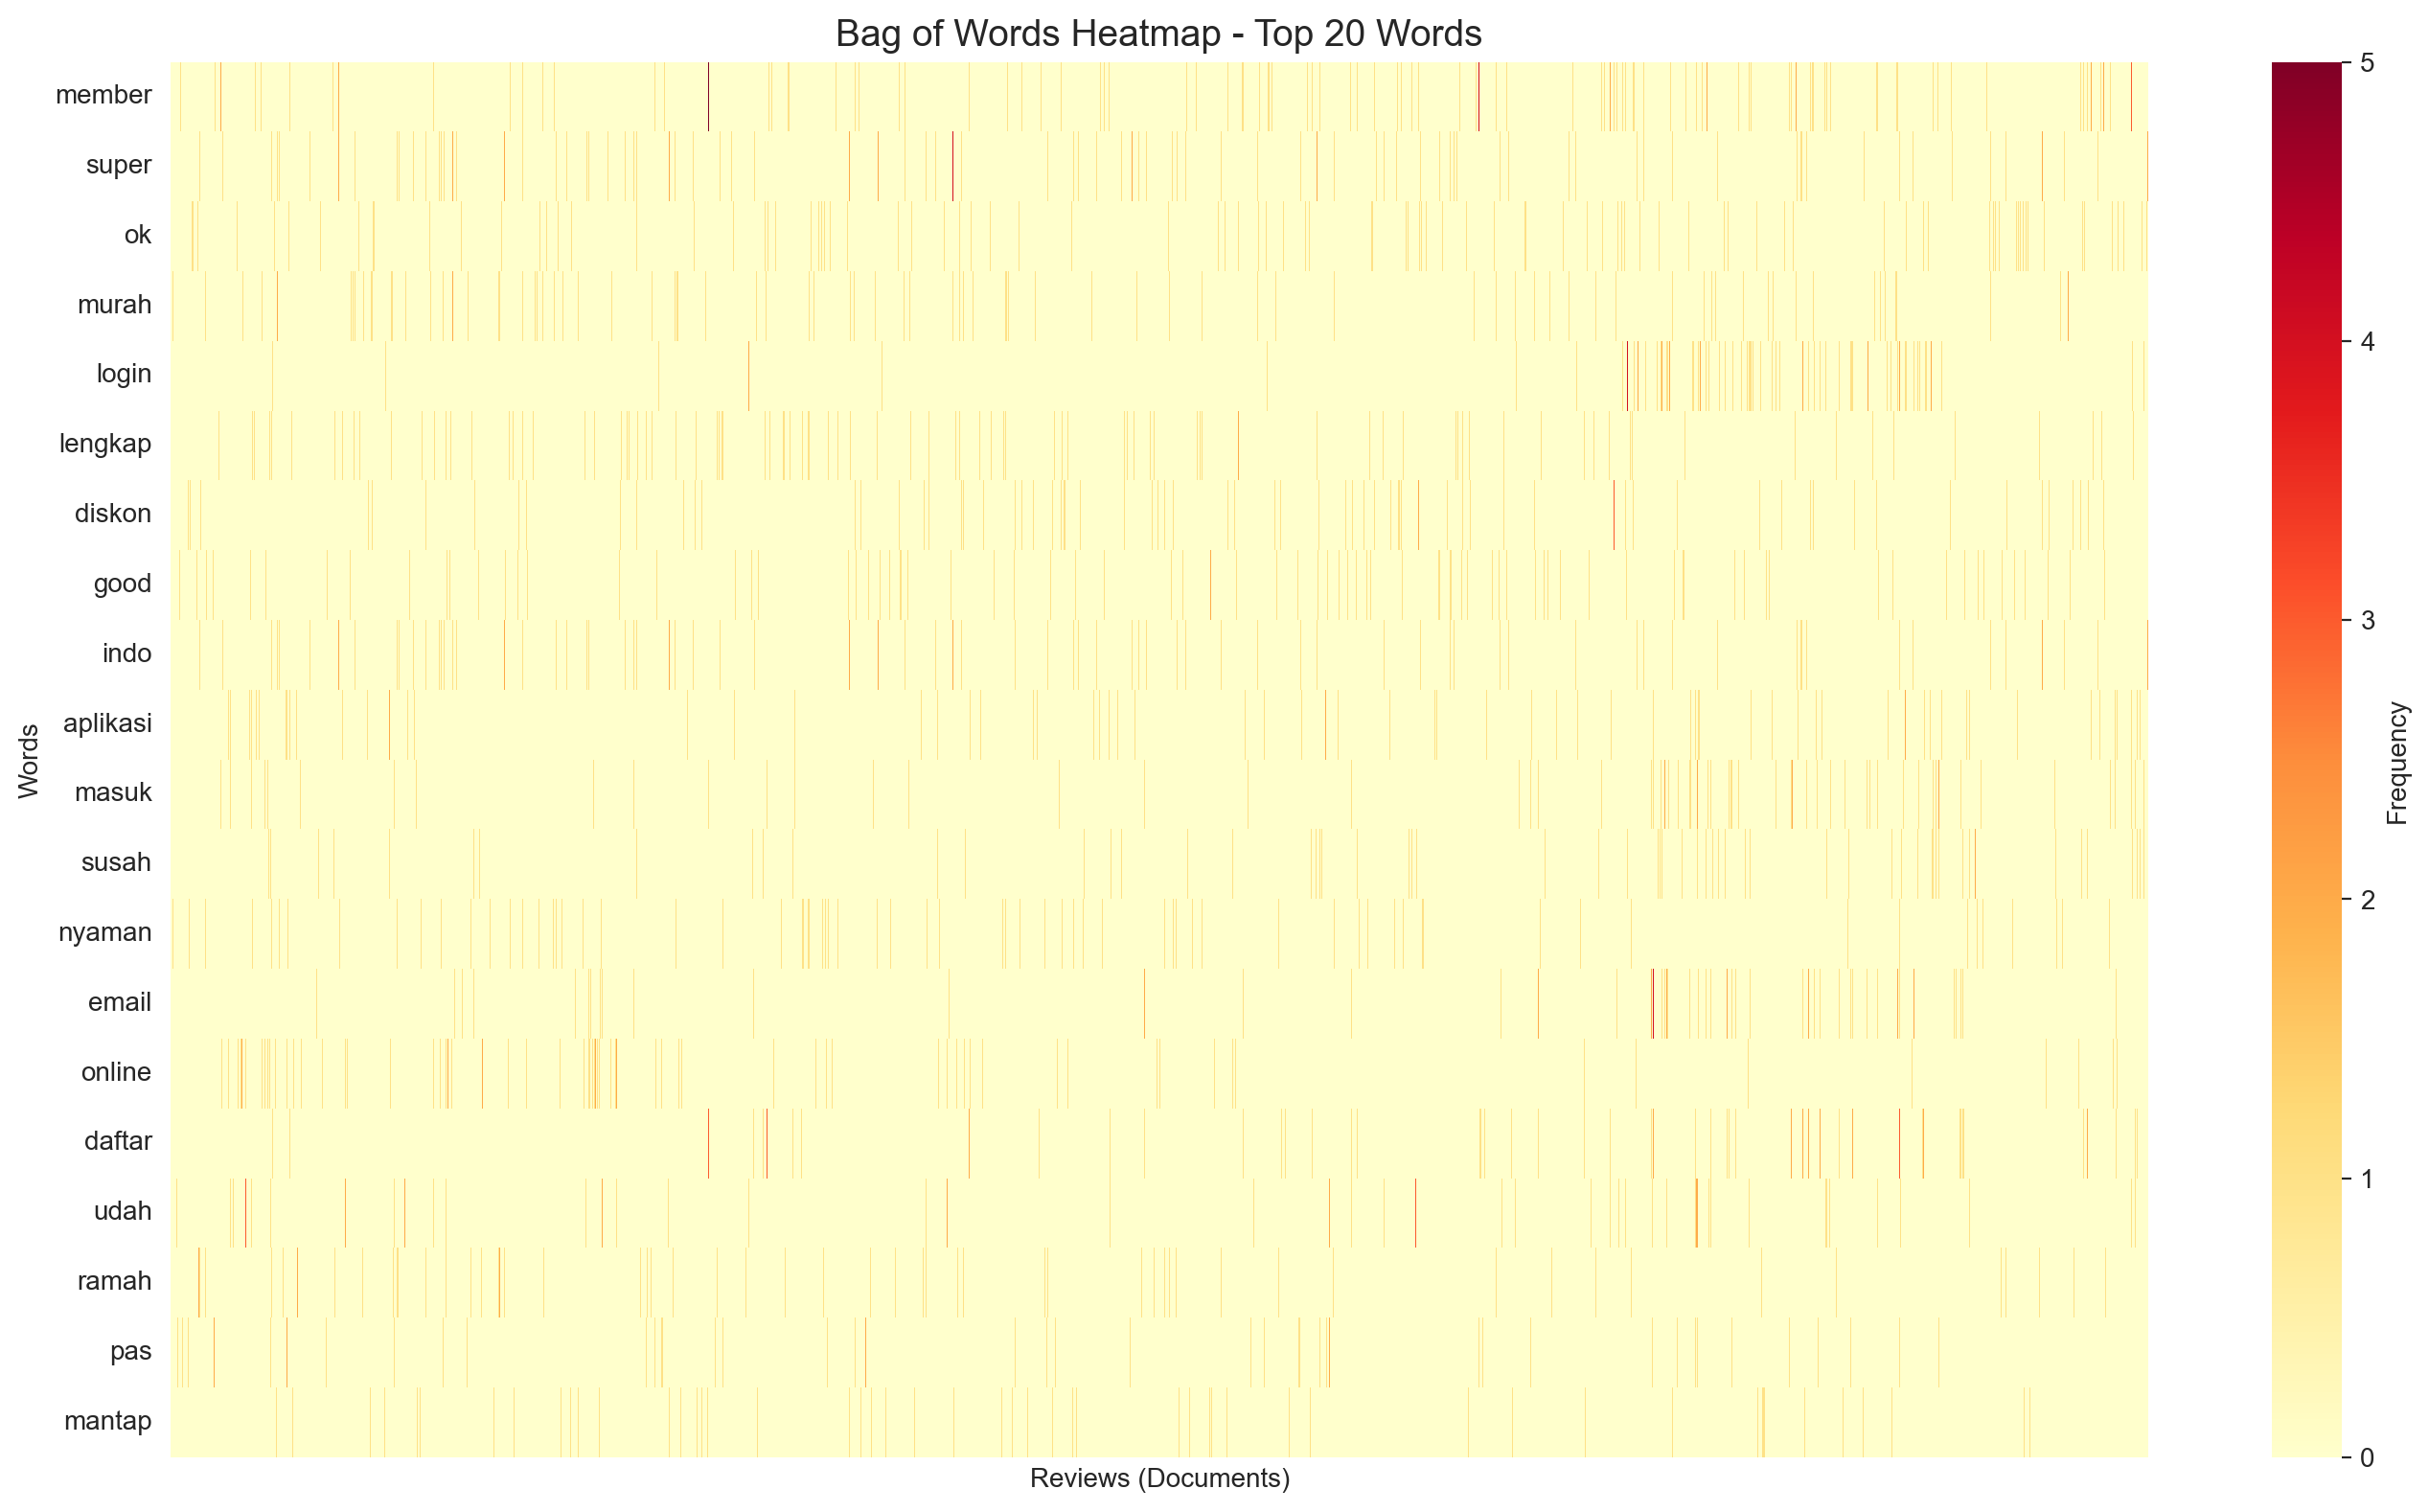


Bag of Words Statistics:
   Total unique words (features): 100
   Total word occurrences: 9637
   Average words per document: 1.93
   Sparsity: 98.25%


In [39]:
# 6. BoW Heatmap - Co-occurrence Analysis
print("="*80)
print("HEATMAP BAG OF WORDS")
print("="*80)

# Ambil top 20 kata
top_words = word_frequencies.head(20).index.tolist()
bow_df_top = bow_df[top_words]

# Buat heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    bow_df_top.T,
    cbar_kws={'label': 'Frequency'},
    cmap='YlOrRd',
    ax=ax,
    xticklabels=False
)
ax.set_title("Bag of Words Heatmap - Top 20 Words", fontsize=14)
ax.set_ylabel("Words")
ax.set_xlabel("Reviews (Documents)")
plt.tight_layout()
plt.show()

# 7. Statistik BoW keseluruhan
print("\nBag of Words Statistics:")
print(f"   Total unique words (features): {len(feature_names)}")
print(f"   Total word occurrences: {bow_matrix.sum()}")
print(f"   Average words per document: {bow_matrix.sum() / bow_matrix.shape[0]:.2f}")
print(f"   Sparsity: {1 - (bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])):.2%}")


In [40]:
# 8. Export Bag of Words Results
print("\n" + "="*80)
print("EXPORT BAG OF WORDS RESULTS")
print("="*80)

# Simpan BoW matrix sebagai DataFrame CSV
bow_output_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=feature_names
)

# Tambahkan kolom label sentiment
bow_output_df['sentiment_rating'] = df_mysuperindo['sentiment_rating'].values
bow_output_df['score'] = df_mysuperindo['score'].values
bow_output_df['original_text'] = df_mysuperindo['content'].values

# Simpan ke CSV
bow_filename = 'mysuperindo_reviews_bow_features.csv'
bow_output_df.to_csv(bow_filename, index=False)
print(f"✓ Bag of Words features saved: {bow_filename}")
print(f"  Shape: {bow_output_df.shape}")

# Simpan statistik kata
word_stats_df = pd.DataFrame({
    'Word': word_frequencies.index,
    'Frequency': word_frequencies.values
})

word_stats_filename = 'mysuperindo_bow_word_statistics.csv'
word_stats_df.to_csv(word_stats_filename, index=False)
print(f"✓ Word statistics saved: {word_stats_filename}")

# Simpan top words per sentiment
sentiment_words_data = []
for sentiment in sorted(df_mysuperindo['sentiment_rating'].unique()):
    sentiment_texts = df_mysuperindo[df_mysuperindo['sentiment_rating'] == sentiment]['clean_text']
    vectorizer_sentiment = CountVectorizer(max_features=20, min_df=2)
    bow_sentiment = vectorizer_sentiment.fit_transform(sentiment_texts)
    feature_names_sentiment = vectorizer_sentiment.get_feature_names_out()
    word_freq_sentiment = bow_sentiment.sum(axis=0).A1
    
    for word, freq in zip(feature_names_sentiment, word_freq_sentiment):
        sentiment_words_data.append({
            'Sentiment': sentiment,
            'Word': word,
            'Frequency': freq
        })

sentiment_words_df = pd.DataFrame(sentiment_words_data)
sentiment_words_filename = 'mysuperindo_bow_words_by_sentiment.csv'
sentiment_words_df.to_csv(sentiment_words_filename, index=False)
print(f"✓ Words by sentiment saved: {sentiment_words_filename}")

print("\n" + "="*80)
print("✅ BAG OF WORDS ANALYSIS COMPLETED!")
print("="*80)
print("\nSummary:")
print(f"   • Total documents: {bow_output_df.shape[0]}")
print(f"   • Total features (words): {len(feature_names)}")
print(f"   • Most frequent word: '{word_frequencies.index[0]}' ({word_frequencies.values[0]} occurrences)")
print(f"   • Least frequent word: '{word_frequencies.index[-1]}' ({word_frequencies.values[-1]} occurrences)")



EXPORT BAG OF WORDS RESULTS
✓ Bag of Words features saved: mysuperindo_reviews_bow_features.csv
  Shape: (5000, 103)
✓ Word statistics saved: mysuperindo_bow_word_statistics.csv
✓ Words by sentiment saved: mysuperindo_bow_words_by_sentiment.csv

✅ BAG OF WORDS ANALYSIS COMPLETED!

Summary:
   • Total documents: 5000
   • Total features (words): 100
   • Most frequent word: 'member' (251 occurrences)
   • Least frequent word: 'akun' (47 occurrences)


## Analisis Regex (Regular Expression) pada Ulasan

Menganalisis pola teks menggunakan regex untuk mendeteksi patterns khusus seperti emoticon, ALL CAPS keywords, komplain, dan kategorisasi review type.

REGEX ANALYSIS - PATTERN DETECTION ON REVIEWS

1. EMOTICON & EMOJI PATTERN DETECTION
Mendeteksi emoticon dan emoji...

Emoticon & Emoji Statistics:
   happy_emoticon      :    26 reviews (  0.5%) | Total: 27
   sad_emoticon        :     5 reviews (  0.1%) | Total: 5
   wink_emoticon       :     0 reviews (  0.0%) | Total: 0
   love_emoticon       :     2 reviews (  0.0%) | Total: 2
   emoji_smile         :    47 reviews (  0.9%) | Total: 57
   emoji_sad           :    31 reviews (  0.6%) | Total: 47
   emoji_angry         :    10 reviews (  0.2%) | Total: 10


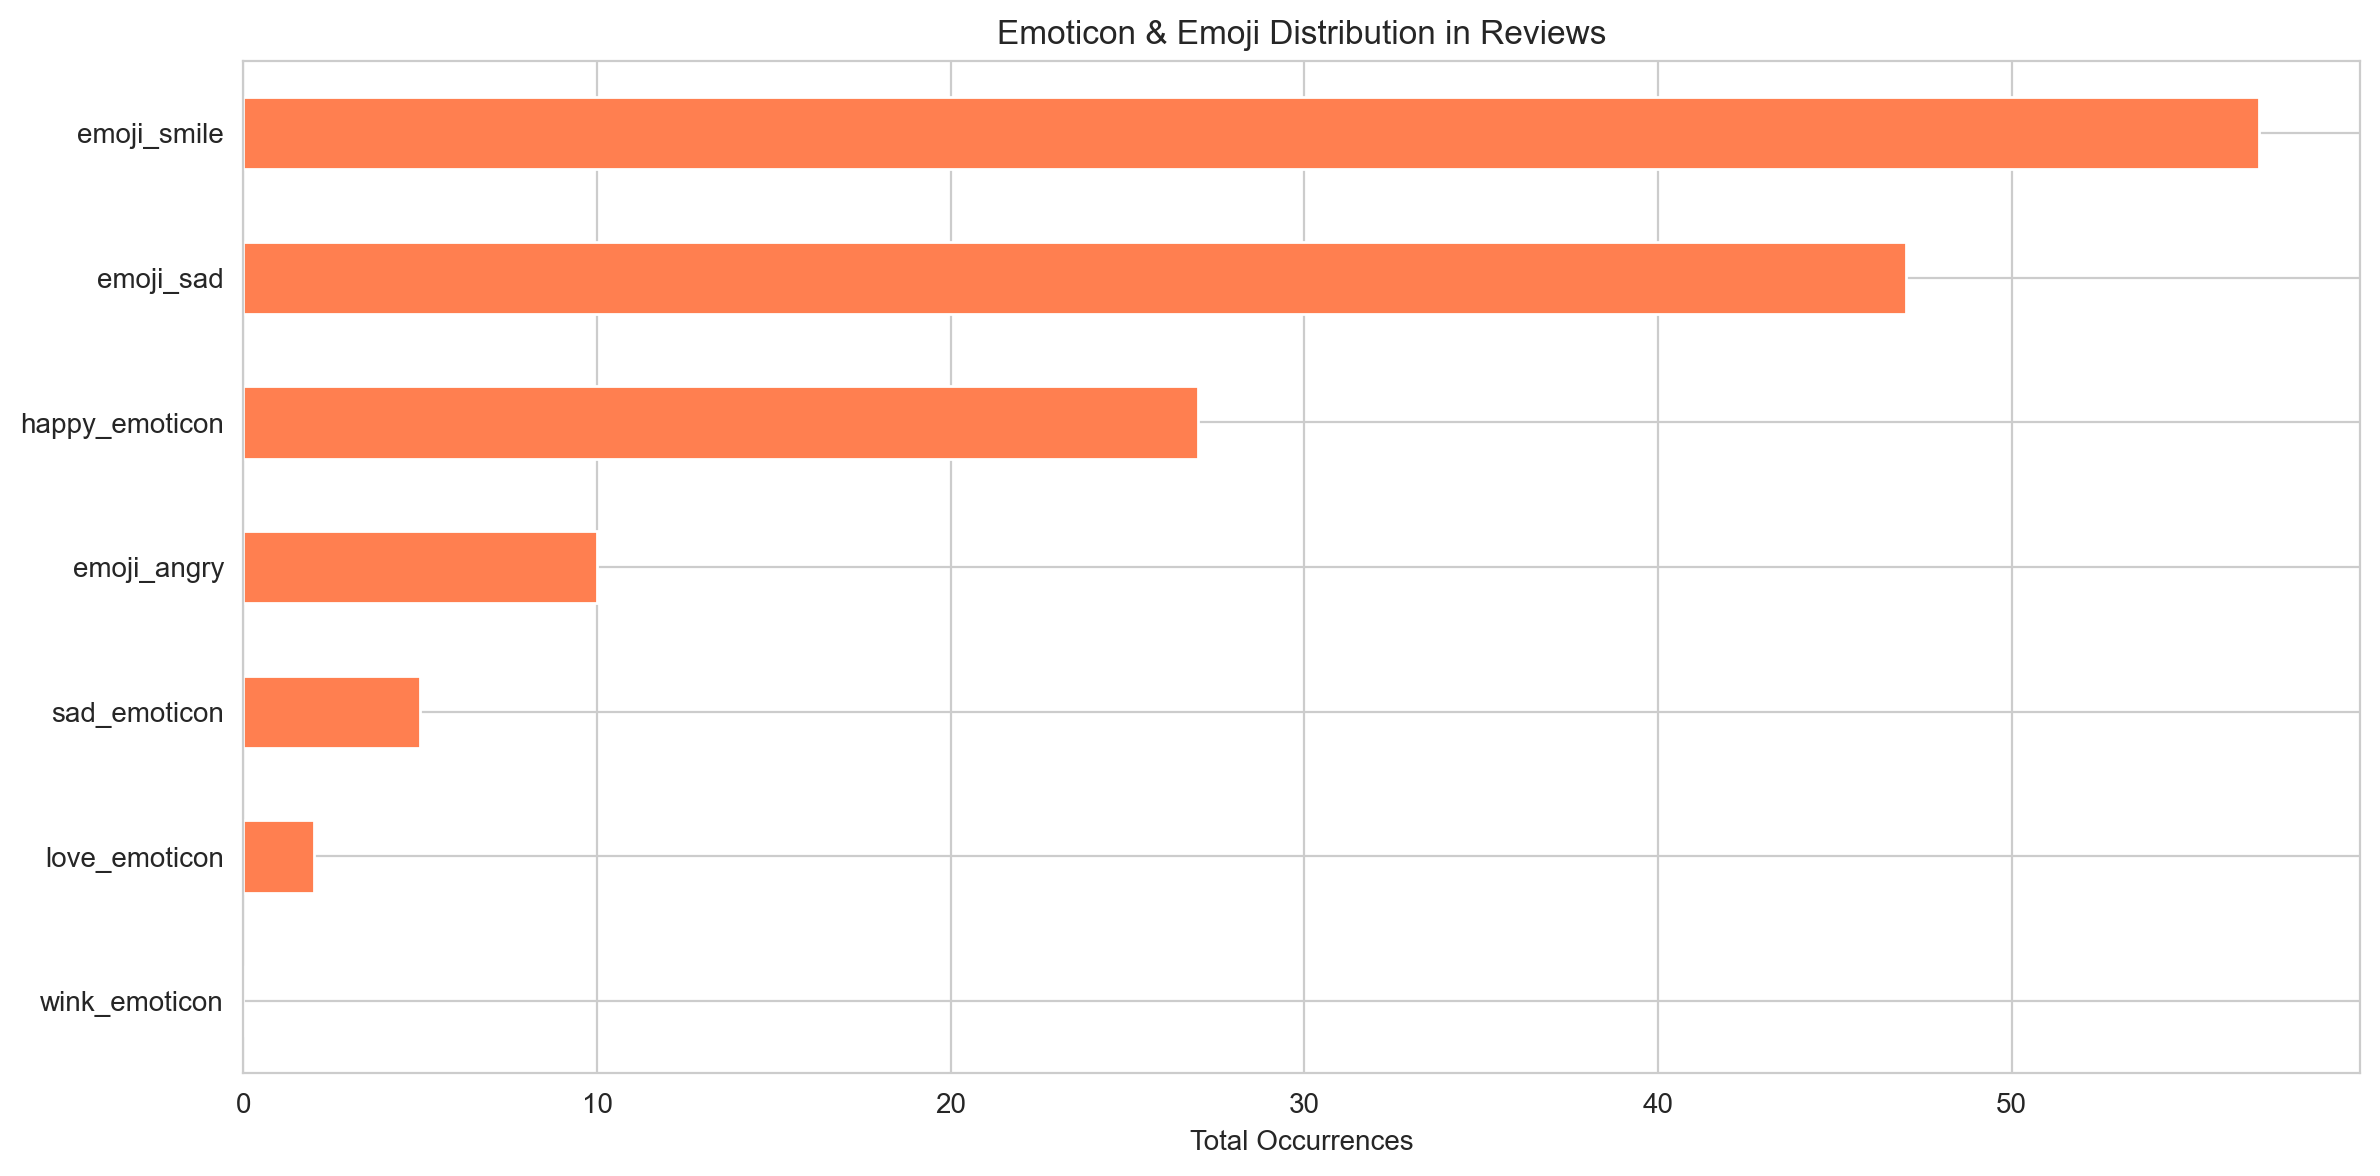


Sample Reviews dengan Emoticon:
1. mayan Promonya 😁...
2. belanja online lewat app superindo sangat tidak direkomendasi. 1. jika beli 1 kg...
3. kenapa appl my super indo punya saya ada "mencari toko terdekat", ya??? 😔🥲🥲🥲🥲...
4. mencari toko terdekat terus ,,lama jadi gk bisa di buka app nya ,,,,😔...
5. digital stickernya ilang semua jadi 0 setelah update aplikasi😞...


In [41]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("REGEX ANALYSIS - PATTERN DETECTION ON REVIEWS")
print("="*80)

# ============================================================================
# 1. EMOTICON & EMOJI PATTERN DETECTION
# ============================================================================
print("\n" + "="*80)
print("1. EMOTICON & EMOJI PATTERN DETECTION")
print("="*80)

# Pattern untuk emoticon dan emoji
emoticon_patterns = {
    'happy_emoticon': r'[:;=]-?[\)\D]|[:;=]-?D',  # :) :D ;) dll
    'sad_emoticon': r'[:;=]-?[\(\[]|D:',  # :( :[ :'( D: dll
    'wink_emoticon': r';-?\)',  # ;) 
    'love_emoticon': r'<3|♥|♡',  # <3 atau heart emoji
    'emoji_smile': r'😊|😁|🙂|😄|😃|😆',  # Smile emoji
    'emoji_sad': r'😢|😭|😞|😔|😟',  # Sad emoji
    'emoji_angry': r'😠|😡|🤬|😤',  # Angry emoji
}

def detect_emoticon(text):
    """Deteksi emoticon dan emoji dalam teks"""
    if pd.isna(text):
        return {}
    
    text = str(text)
    detected = {}
    
    for emotion, pattern in emoticon_patterns.items():
        matches = re.findall(pattern, text, re.UNICODE)
        detected[emotion] = len(matches)
    
    return detected

# Terapkan deteksi emoticon
print("Mendeteksi emoticon dan emoji...")
emoticon_detection = df_mysuperindo['content'].apply(detect_emoticon)
emoticon_df = pd.DataFrame(list(emoticon_detection))

# Tambahkan ke dataframe
for col in emoticon_df.columns:
    df_mysuperindo[f'emoticon_{col}'] = emoticon_df[col]

# Statistik emoticon
print("\nEmoticon & Emoji Statistics:")
for col in emoticon_df.columns:
    count = (emoticon_df[col] > 0).sum()
    pct = (count / len(emoticon_df)) * 100
    total = emoticon_df[col].sum()
    print(f"   {col:20s}: {count:5d} reviews ({pct:5.1f}%) | Total: {int(total)}")

# Visualisasi emoticon distribution
fig, ax = plt.subplots(figsize=(12, 6))
emoticon_totals = emoticon_df.sum().sort_values(ascending=True)
emoticon_totals.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel("Total Occurrences")
ax.set_title("Emoticon & Emoji Distribution in Reviews")
plt.tight_layout()
plt.show()

print("\nSample Reviews dengan Emoticon:")
reviews_with_emoticon = df_mysuperindo[emoticon_df.sum(axis=1) > 0]['content'].head(5)
for i, review in enumerate(reviews_with_emoticon, 1):
    print(f"{i}. {review[:80]}...")



2. ALL CAPS KEYWORDS DETECTION (Indikasi Emosi Kuat)
Penjelasan: Kata-kata yang ditulis SEPENUHNYA HURUF BESAR menunjukkan emosi
            kuat (biasanya kemarahan, kejutan, atau kepuasan ekstrem)
Mendeteksi ALL CAPS keywords...

ALL CAPS Statistics:
   Reviews dengan CAPS: 204 (4.1%)
   Total CAPS words: 676
   Average CAPS per review: 0.14

Top 15 ALL CAPS Words yang paling sering:
   SUPERINDO      :  14 occurrences
   DAN            :  14 occurrences
   GA             :  12 occurrences
   HP             :  12 occurrences
   JSM            :  10 occurrences
   APLIKASI       :  10 occurrences
   CS             :   9 occurrences
   BISA           :   9 occurrences
   REFUND         :   9 occurrences
   GK             :   8 occurrences
   AI             :   8 occurrences
   GAK            :   7 occurrences
   DI             :   7 occurrences
   DM             :   7 occurrences
   SUPER          :   7 occurrences


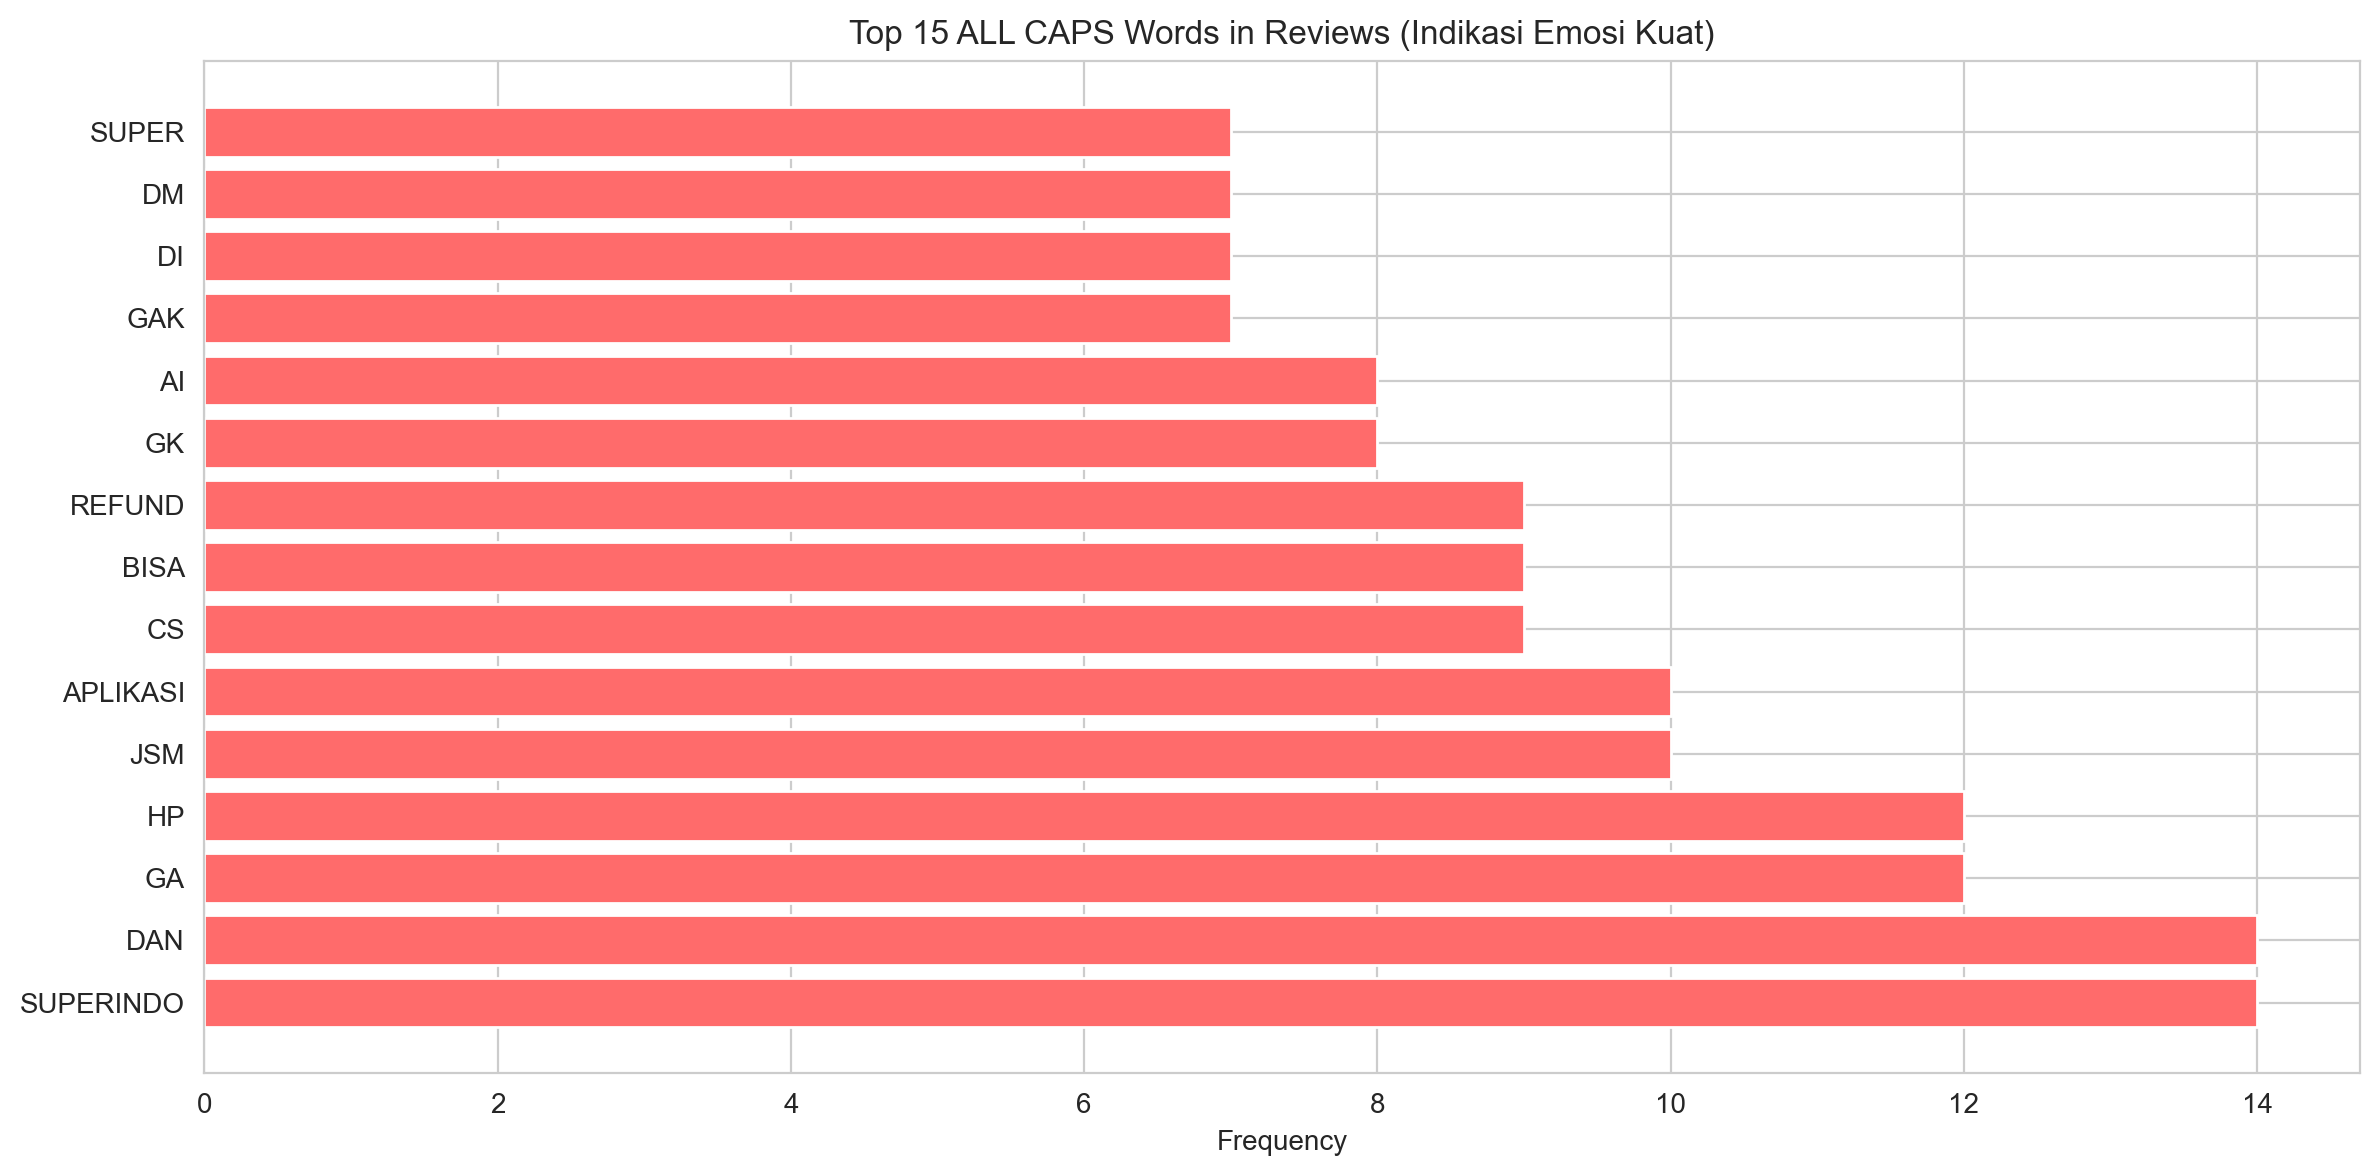


ALL CAPS vs Sentiment Analysis:
                      mean  count
sentiment_rating                 
Negative          0.385449   1292
Neutral           0.081911    293
Positive          0.045095   3415

Sample Reviews dengan banyak CAPS:
1. CAPS Count: 57 | Sentiment: Negative
   Kasih bintang 1. AJA. Makin ke SINI MSI NYA BIKIN BINGUNG KE PELANGGAN. DAN BIKI...

2. CAPS Count: 54 | Sentiment: Negative
   TIDAK BISA REFUND ! KENAPA ? KOK SULIT BANGET BUAT REFUND ? SALAH KALIAN SETTING...

3. CAPS Count: 37 | Sentiment: Negative
   Please JANGAN PERNAH ADA YG INSTAL NIH APLIKASI APALAGI BELANJA VIA APK NYA KARN...



In [42]:
# ============================================================================
# 2. ALL CAPS KEYWORDS DETECTION (Indikasi Emosi Kuat)
# ============================================================================
print("\n" + "="*80)
print("2. ALL CAPS KEYWORDS DETECTION (Indikasi Emosi Kuat)")
print("="*80)
print("Penjelasan: Kata-kata yang ditulis SEPENUHNYA HURUF BESAR menunjukkan emosi")
print("            kuat (biasanya kemarahan, kejutan, atau kepuasan ekstrem)")

# Pattern untuk mendeteksi ALL CAPS words (minimal 2 huruf)
all_caps_pattern = r'\b[A-Z]{2,}\b'

def detect_all_caps(text):
    """Deteksi dan hitung ALL CAPS words"""
    if pd.isna(text):
        return 0
    
    text = str(text)
    matches = re.findall(all_caps_pattern, text)
    return len(matches)

def get_all_caps_words(text):
    """Ambil semua ALL CAPS words sebagai list"""
    if pd.isna(text):
        return []
    
    text = str(text)
    matches = re.findall(all_caps_pattern, text)
    return matches

# Terapkan deteksi
print("Mendeteksi ALL CAPS keywords...")
df_mysuperindo['caps_count'] = df_mysuperindo['content'].apply(detect_all_caps)
df_mysuperindo['caps_words'] = df_mysuperindo['content'].apply(get_all_caps_words)

# Statistik
print(f"\nALL CAPS Statistics:")
print(f"   Reviews dengan CAPS: {(df_mysuperindo['caps_count'] > 0).sum()} ({(df_mysuperindo['caps_count'] > 0).sum()/len(df_mysuperindo)*100:.1f}%)")
print(f"   Total CAPS words: {df_mysuperindo['caps_count'].sum()}")
print(f"   Average CAPS per review: {df_mysuperindo['caps_count'].mean():.2f}")

# Hitung semua CAPS words yang sering muncul
all_caps_words_list = [word for words_list in df_mysuperindo['caps_words'] for word in words_list]
from collections import Counter
caps_frequency = Counter(all_caps_words_list)

print(f"\nTop 15 ALL CAPS Words yang paling sering:")
for word, count in caps_frequency.most_common(15):
    print(f"   {word:15s}: {count:3d} occurrences")

# Visualisasi
top_caps_words = dict(caps_frequency.most_common(15))
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(list(top_caps_words.keys()), list(top_caps_words.values()), color='#ff6b6b')
ax.set_xlabel("Frequency")
ax.set_title("Top 15 ALL CAPS Words in Reviews (Indikasi Emosi Kuat)")
plt.tight_layout()
plt.show()

# Korelasi CAPS dengan sentiment
print(f"\nALL CAPS vs Sentiment Analysis:")
caps_sentiment = df_mysuperindo.groupby('sentiment_rating')['caps_count'].agg(['mean', 'count'])
print(caps_sentiment)

print("\nSample Reviews dengan banyak CAPS:")
high_caps = df_mysuperindo[df_mysuperindo['caps_count'] >= 3].nlargest(3, 'caps_count')
for idx, (i, row) in enumerate(high_caps.iterrows(), 1):
    print(f"{idx}. CAPS Count: {row['caps_count']} | Sentiment: {row['sentiment_rating']}")
    print(f"   {row['content'][:80]}...\n")



3. URL, EMAIL, DAN HASHTAG EXTRACTION
Penjelasan: Ekstrak pola URL, email, dan hashtag dari ulasan untuk analisis
            kualitas informasi dan referensi yang disertakan
Mengekstrak URL, Email, Hashtag, dan Mentions...

Extraction Statistics:
   Reviews dengan URL    :    0 (  0.0%)
   Reviews dengan Email  :    0 (  0.0%)
   Reviews dengan Hashtag:    2 (  0.0%)
   Reviews dengan Mention:    1 (  0.0%)

Top 10 Hashtags yang digunakan:
   #PakaiHati: 1 times
   #superindo: 1 times


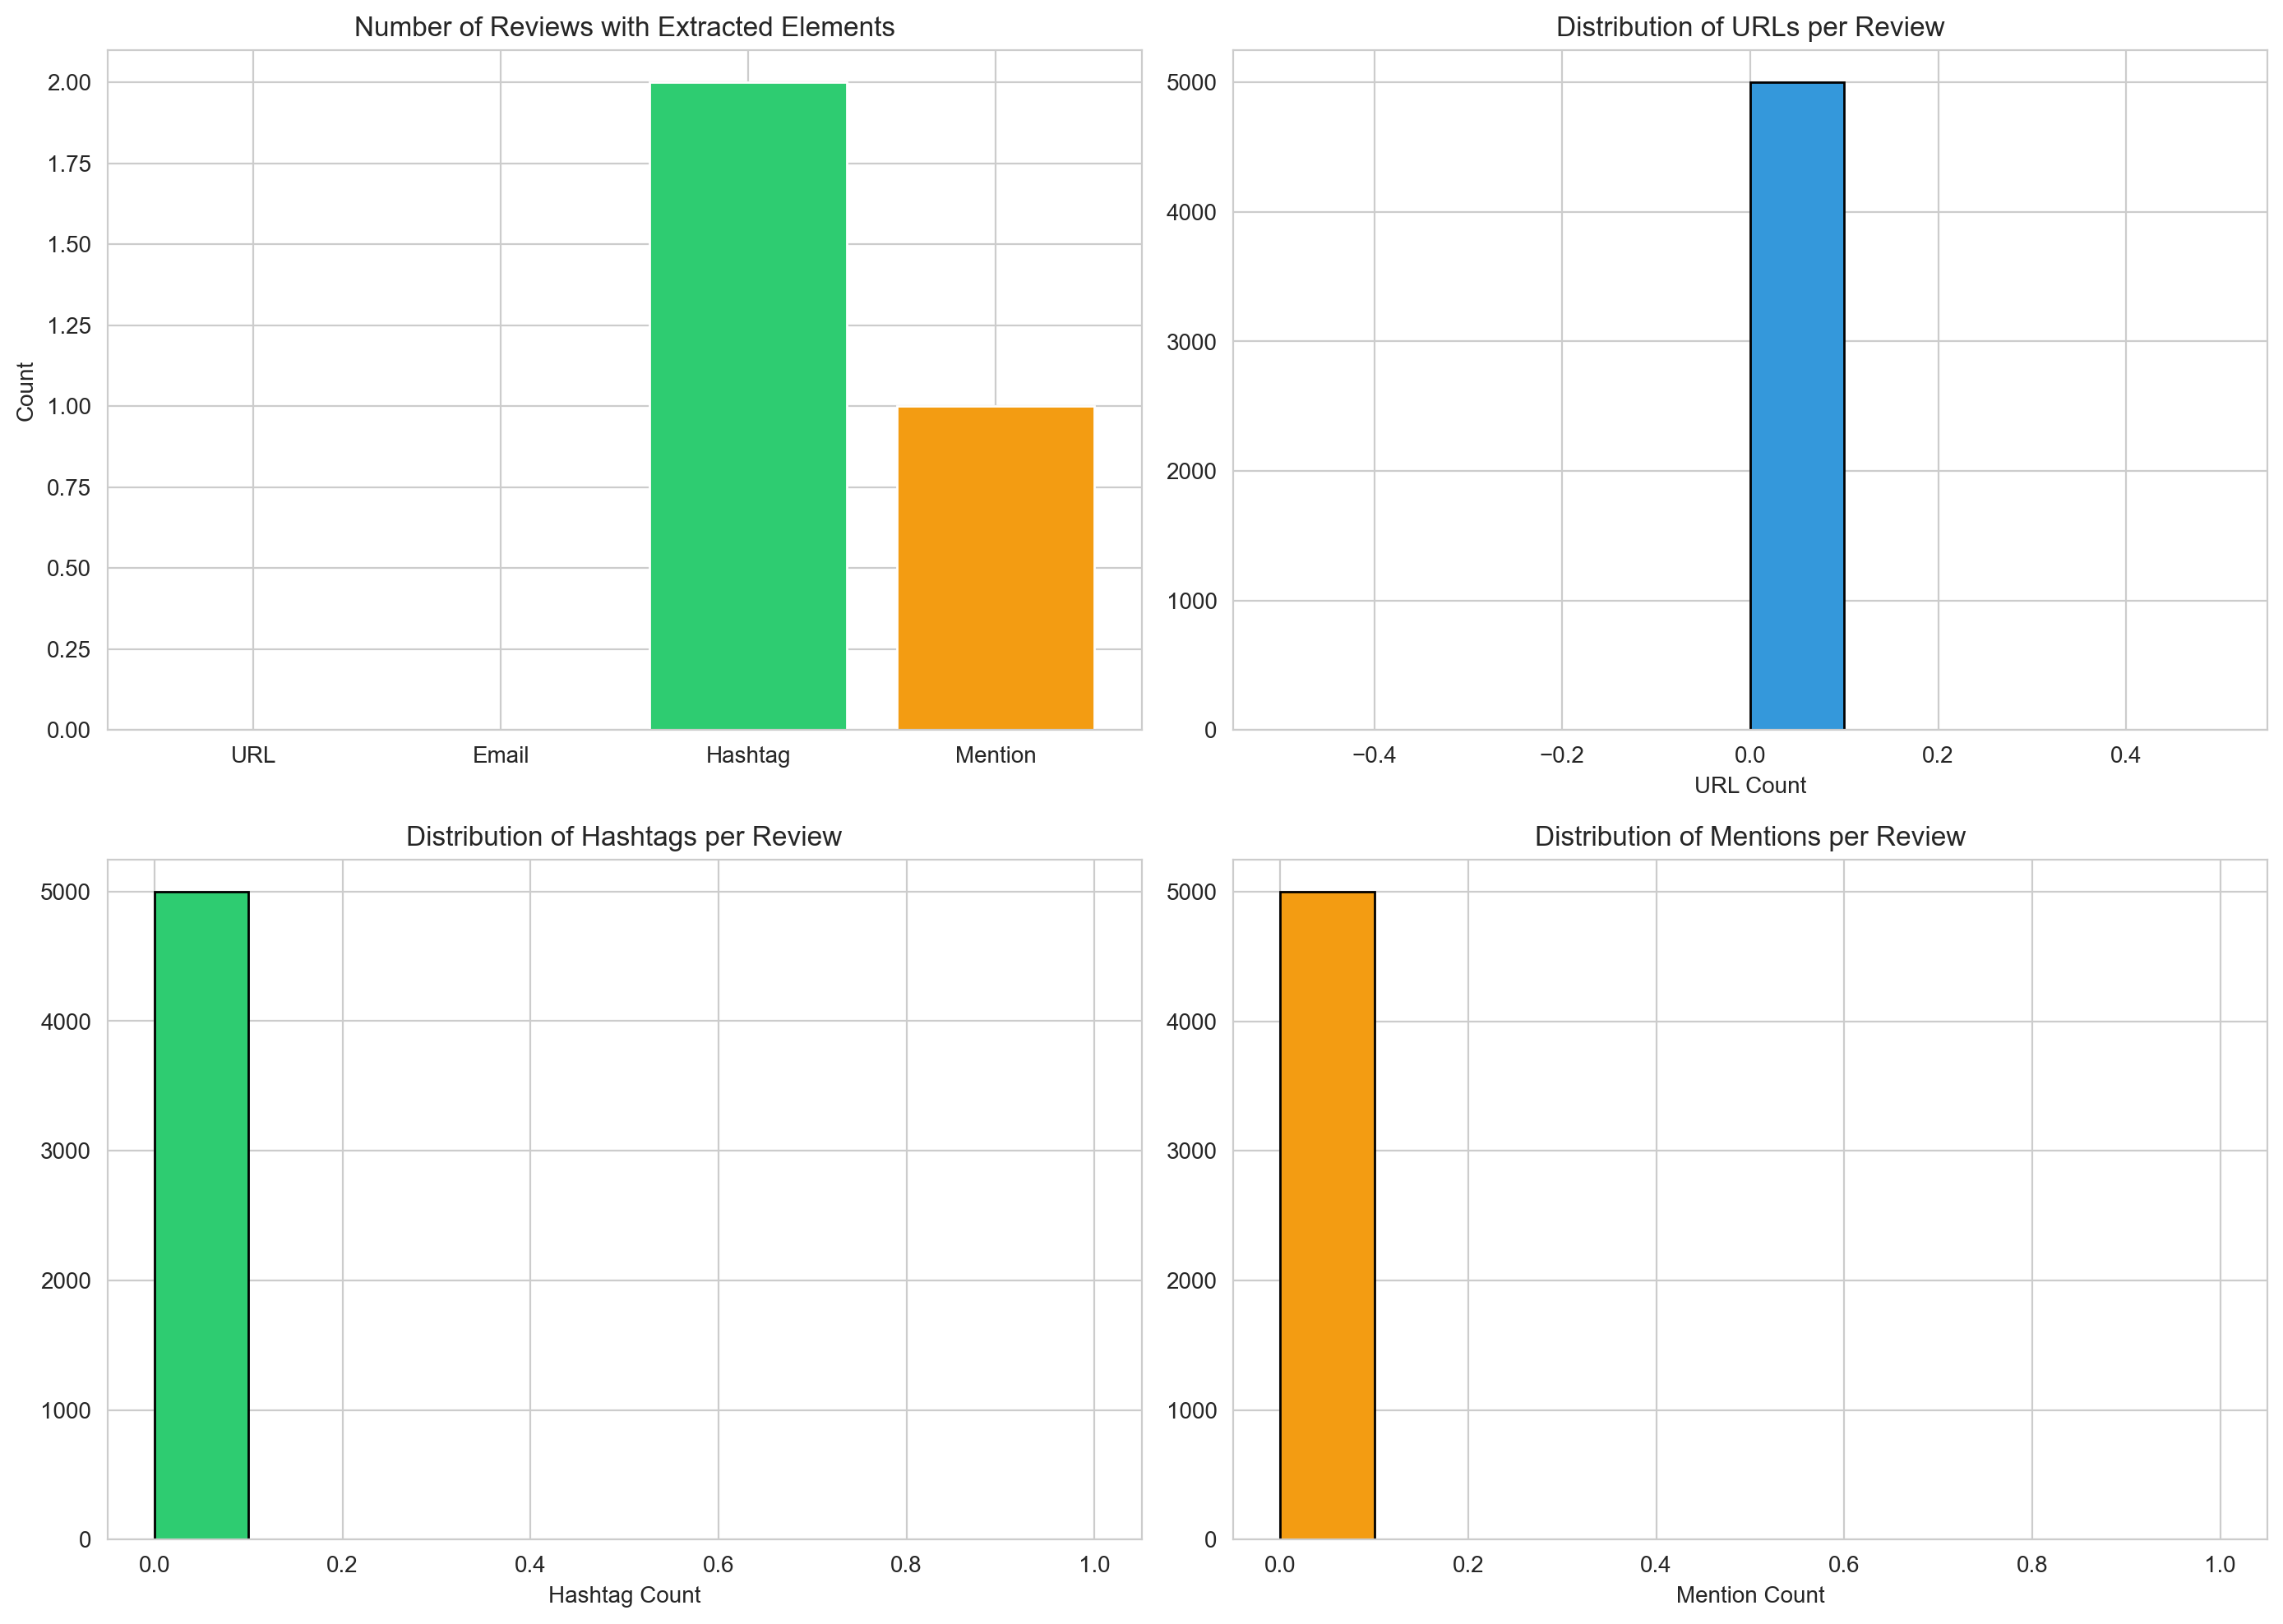


Sample Reviews dengan URL/Hashtag:
1. URLs: [] | Hashtags: ['#PakaiHati']
   Sangat bermanfaat.. menguntungkan.. dan tentunya menyegarkan... Superindo #Pakai...

2. URLs: [] | Hashtags: ['#superindo']
   Belanja nyaman harga terbaik..ya #superindo...



In [43]:
# ============================================================================
# 3. URL, EMAIL, DAN HASHTAG EXTRACTION
# ============================================================================
print("\n" + "="*80)
print("3. URL, EMAIL, DAN HASHTAG EXTRACTION")
print("="*80)
print("Penjelasan: Ekstrak pola URL, email, dan hashtag dari ulasan untuk analisis")
print("            kualitas informasi dan referensi yang disertakan")

# Regex patterns untuk ekstraksi
url_pattern = r'https?://\S+|www\.\S+'  # URL
email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'  # Email
hashtag_pattern = r'#\w+'  # Hashtag
mention_pattern = r'@\w+'  # Mentions

def extract_pattern(text, pattern):
    """Ekstrak pattern dari teks"""
    if pd.isna(text):
        return []
    
    text = str(text)
    matches = re.findall(pattern, text, re.UNICODE)
    return matches

# Terapkan ekstraksi
print("Mengekstrak URL, Email, Hashtag, dan Mentions...")
df_mysuperindo['urls'] = df_mysuperindo['content'].apply(lambda x: extract_pattern(x, url_pattern))
df_mysuperindo['emails'] = df_mysuperindo['content'].apply(lambda x: extract_pattern(x, email_pattern))
df_mysuperindo['hashtags'] = df_mysuperindo['content'].apply(lambda x: extract_pattern(x, hashtag_pattern))
df_mysuperindo['mentions'] = df_mysuperindo['content'].apply(lambda x: extract_pattern(x, mention_pattern))

# Hitung jumlah
df_mysuperindo['url_count'] = df_mysuperindo['urls'].apply(len)
df_mysuperindo['email_count'] = df_mysuperindo['emails'].apply(len)
df_mysuperindo['hashtag_count'] = df_mysuperindo['hashtags'].apply(len)
df_mysuperindo['mention_count'] = df_mysuperindo['mentions'].apply(len)

# Statistik
print(f"\nExtraction Statistics:")
print(f"   Reviews dengan URL    : {(df_mysuperindo['url_count'] > 0).sum():4d} ({(df_mysuperindo['url_count'] > 0).sum()/len(df_mysuperindo)*100:5.1f}%)")
print(f"   Reviews dengan Email  : {(df_mysuperindo['email_count'] > 0).sum():4d} ({(df_mysuperindo['email_count'] > 0).sum()/len(df_mysuperindo)*100:5.1f}%)")
print(f"   Reviews dengan Hashtag: {(df_mysuperindo['hashtag_count'] > 0).sum():4d} ({(df_mysuperindo['hashtag_count'] > 0).sum()/len(df_mysuperindo)*100:5.1f}%)")
print(f"   Reviews dengan Mention: {(df_mysuperindo['mention_count'] > 0).sum():4d} ({(df_mysuperindo['mention_count'] > 0).sum()/len(df_mysuperindo)*100:5.1f}%)")

# Konten URL, Email, Hashtag yang diekstrak
if df_mysuperindo['urls'].apply(len).sum() > 0:
    all_urls = [url for urls_list in df_mysuperindo['urls'] for url in urls_list]
    print(f"\nTop 10 URLs yang disebut:")
    for url, count in Counter(all_urls).most_common(10):
        print(f"   {url}")

if df_mysuperindo['hashtags'].apply(len).sum() > 0:
    all_hashtags = [tag for tags_list in df_mysuperindo['hashtags'] for tag in tags_list]
    print(f"\nTop 10 Hashtags yang digunakan:")
    for tag, count in Counter(all_hashtags).most_common(10):
        print(f"   {tag}: {count} times")

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

extraction_counts = {
    'URL': (df_mysuperindo['url_count'] > 0).sum(),
    'Email': (df_mysuperindo['email_count'] > 0).sum(),
    'Hashtag': (df_mysuperindo['hashtag_count'] > 0).sum(),
    'Mention': (df_mysuperindo['mention_count'] > 0).sum()
}

axes[0, 0].bar(extraction_counts.keys(), extraction_counts.values(), color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0, 0].set_title("Number of Reviews with Extracted Elements")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df_mysuperindo['url_count'], bins=10, color='#3498db', edgecolor='black')
axes[0, 1].set_title("Distribution of URLs per Review")
axes[0, 1].set_xlabel("URL Count")

axes[1, 0].hist(df_mysuperindo['hashtag_count'], bins=10, color='#2ecc71', edgecolor='black')
axes[1, 0].set_title("Distribution of Hashtags per Review")
axes[1, 0].set_xlabel("Hashtag Count")

axes[1, 1].hist(df_mysuperindo['mention_count'], bins=10, color='#f39c12', edgecolor='black')
axes[1, 1].set_title("Distribution of Mentions per Review")
axes[1, 1].set_xlabel("Mention Count")

plt.tight_layout()
plt.show()

print("\nSample Reviews dengan URL/Hashtag:")
reviews_with_refs = df_mysuperindo[(df_mysuperindo['url_count'] > 0) | (df_mysuperindo['hashtag_count'] > 0)].head(3)
for idx, (i, row) in enumerate(reviews_with_refs.iterrows(), 1):
    print(f"{idx}. URLs: {row['urls']} | Hashtags: {row['hashtags']}")
    print(f"   {row['content'][:80]}...\n")



4. COMPLAINT PATTERN DETECTION (Deteksi Pola Keluhan)
Penjelasan: Deteksi review yang berisi keluhan dengan mencari kata/pola
            khusus seperti 'tidak bisa', 'error', 'bug', 'rusak', dll
Mendeteksi pola keluhan...

Complaint Detection Statistics:
   Total Reviews dengan Keluhan: 658 (13.2%)

Complaint Category Breakdown:
   technical_issues    :   291 reviews | Total occurrences: 337
   quality_issues      :   135 reviews | Total occurrences: 149
   missing_features    :   159 reviews | Total occurrences: 179
   performance_issues  :    37 reviews | Total occurrences: 38
   security_concerns   :    14 reviews | Total occurrences: 14
   payment_issues      :   104 reviews | Total occurrences: 138
   customer_service    :    62 reviews | Total occurrences: 79

Complaint Distribution by Sentiment:
   Negative  :  475 / 1292 ( 36.8%)
   Neutral   :   67 /  293 ( 22.9%)
   Positive  :  116 / 3415 (  3.4%)


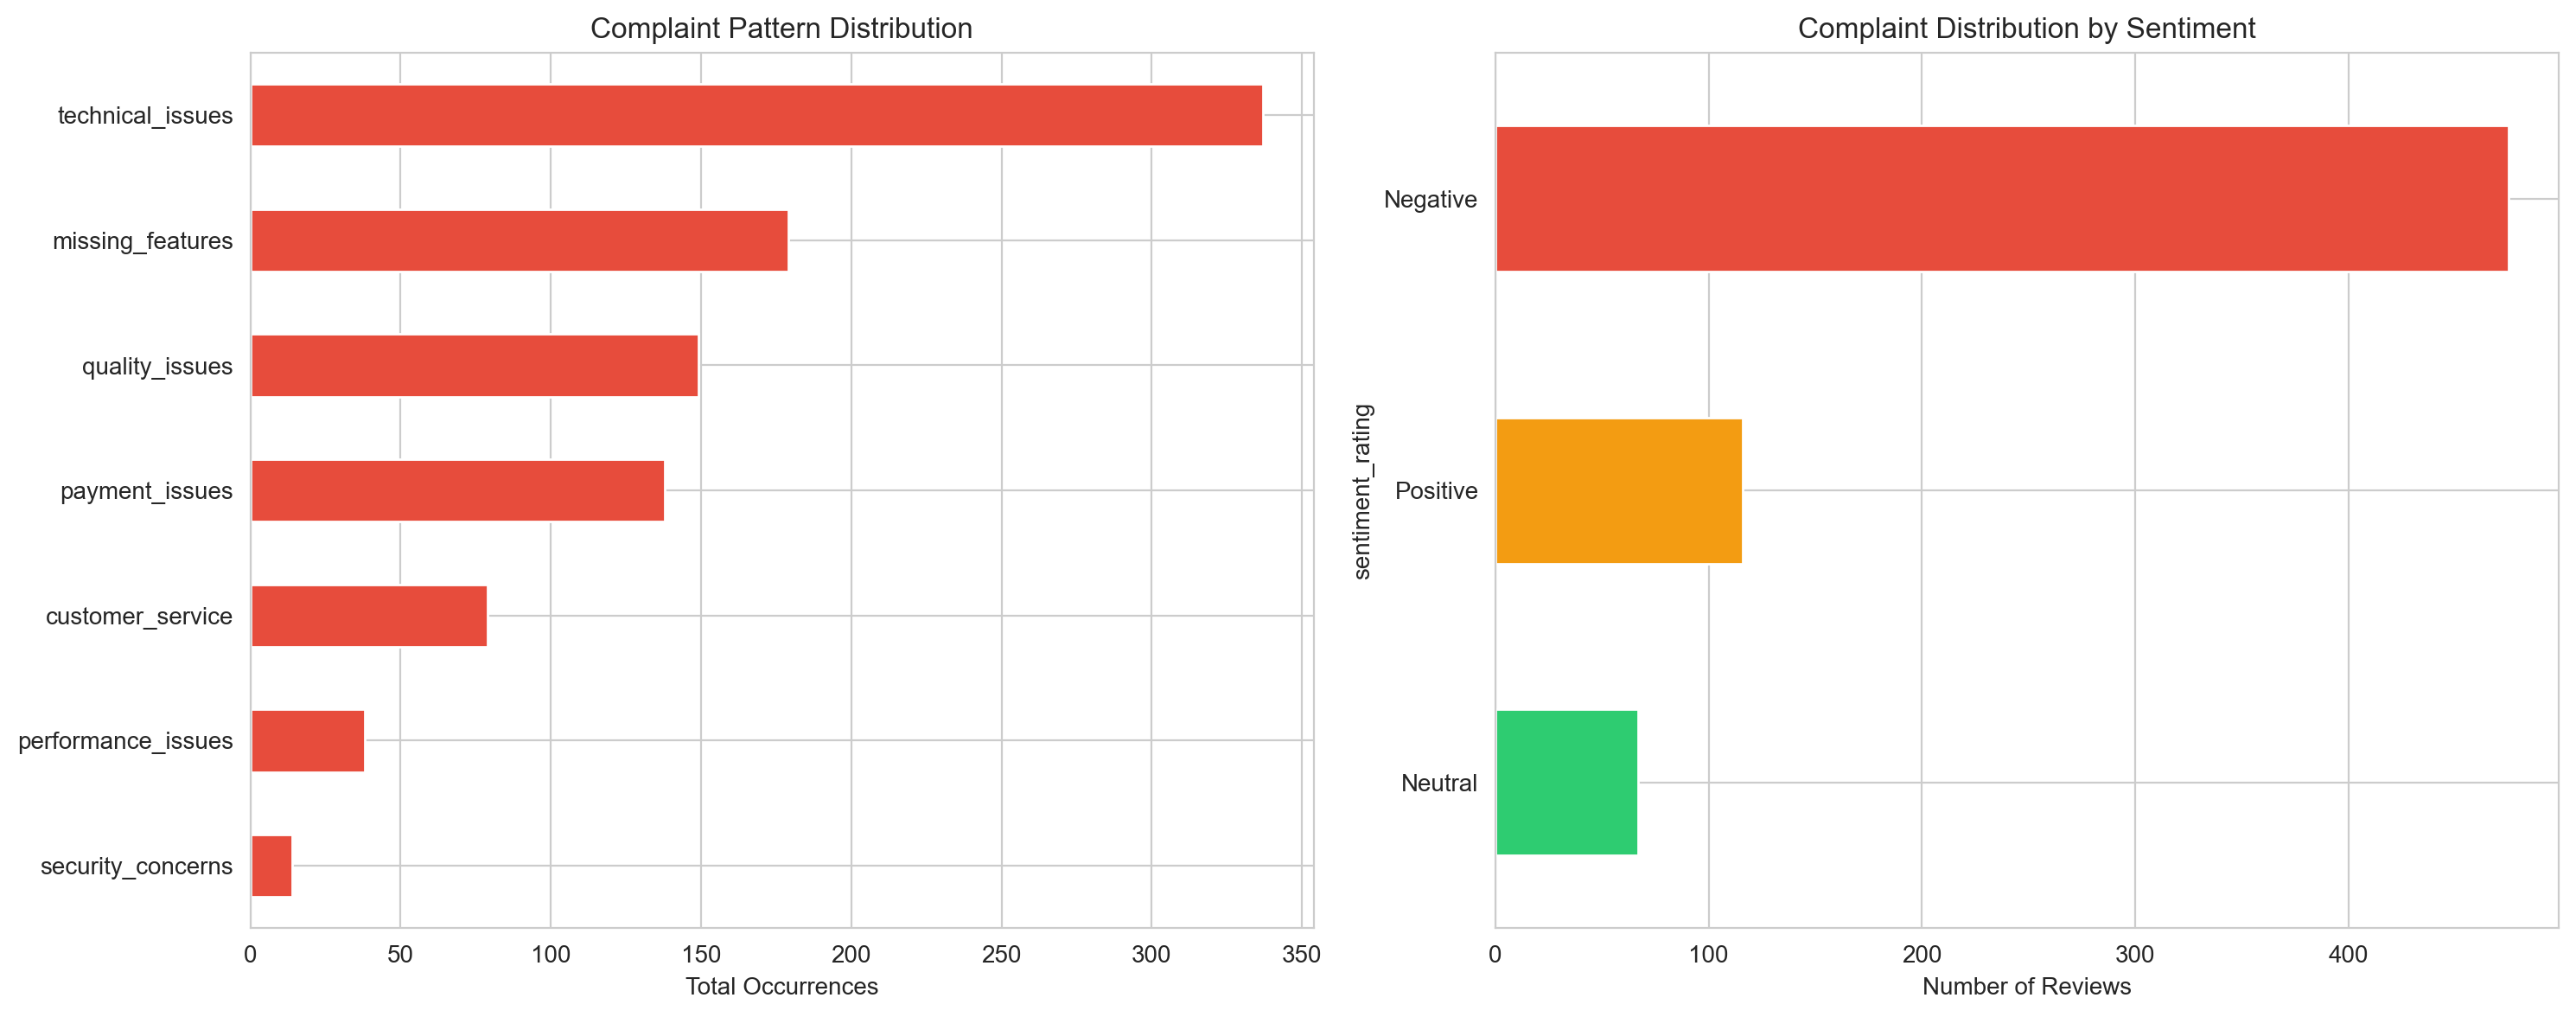


Top 5 High-Complaint Reviews (Most Complaint Patterns):
1. Complaint Count: 6 | Score: 1⭐ | Sentiment: Negative
   Saya kecewa sekali proses refund sangat sulit, cs di telpon via wa dan telpon ru...

2. Complaint Count: 6 | Score: 1⭐ | Sentiment: Negative
   Kocak ni baru mau beri ulasan, ternyata sama banget yg dialamin customer lain. B...

3. Complaint Count: 6 | Score: 1⭐ | Sentiment: Negative
   Sumpah ini aplikasi yg ga worth it digunakan. First time coba belanja pke MSI lg...

4. Complaint Count: 6 | Score: 1⭐ | Sentiment: Negative
   - ga bisa ubah cara pembayaran atau di batalin lalu ubah cara bayar. - sekali pe...

5. Complaint Count: 5 | Score: 5⭐ | Sentiment: Positive
   saya belanja bayar pake VA sudah berhasil tapi di aplikasi blm masuk pembayaran ...



In [44]:
# ============================================================================
# 4. COMPLAINT PATTERN DETECTION (Deteksi Pola Keluhan)
# ============================================================================
print("\n" + "="*80)
print("4. COMPLAINT PATTERN DETECTION (Deteksi Pola Keluhan)")
print("="*80)
print("Penjelasan: Deteksi review yang berisi keluhan dengan mencari kata/pola")
print("            khusus seperti 'tidak bisa', 'error', 'bug', 'rusak', dll")

# Definisikan pola keluhan berbahasa Indonesia
complaint_patterns = {
    'technical_issues': r'\b(error|bug|crash|lag|freeze|slow|tidak bisa|gak bisa|tidak jalan|error apa|tidak berfungsi|tidak bekerja)\b',
    'quality_issues': r'\b(buruk|jelek|kecewa|mengecewakan|kurang bagus|tidak bagus|sampah|jelek banget|rusak|cacat|pecah)\b',
    'missing_features': r'\b(tidak ada|gak ada|hilang|menghilang|tidak lengkap|kurang fitur|mending|seharusnya ada)\b',
    'performance_issues': r'\b(lambat|lelet|berat|memory|crash|hang|stuck|freeze)\b',
    'security_concerns': r'\b(aman|keamanan|privasi|data bocor|hacker|aman tidak)\b',
    'payment_issues': r'\b(bayar|pembayaran|tidak terima|belum terima|tagihan|transaksi|duit|uang)\b',
    'customer_service': r'\b(customer service|cs|admin|kontak|hubungi|bantuan|tidak dibalas|respon|lambat respon)\b',
}

def detect_complaints(text):
    """Deteksi dan hitung pola keluhan"""
    if pd.isna(text):
        return {}
    
    text = str(text).lower()
    detected = {}
    
    for category, pattern in complaint_patterns.items():
        matches = re.findall(pattern, text, re.IGNORECASE)
        detected[category] = len(matches)
    
    return detected

# Terapkan deteksi
print("Mendeteksi pola keluhan...")
complaint_detection = df_mysuperindo['content'].apply(detect_complaints)
complaint_df = pd.DataFrame(list(complaint_detection))

# Tambahkan ke dataframe
for col in complaint_df.columns:
    df_mysuperindo[f'complaint_{col}'] = complaint_df[col]

df_mysuperindo['complaint_total'] = complaint_df.sum(axis=1)
df_mysuperindo['is_complaint'] = df_mysuperindo['complaint_total'] > 0

# Statistik
print(f"\nComplaint Detection Statistics:")
print(f"   Total Reviews dengan Keluhan: {df_mysuperindo['is_complaint'].sum()} ({df_mysuperindo['is_complaint'].sum()/len(df_mysuperindo)*100:.1f}%)")
print(f"\nComplaint Category Breakdown:")
for col in complaint_df.columns:
    count = (complaint_df[col] > 0).sum()
    total = complaint_df[col].sum()
    print(f"   {col:20s}: {count:5d} reviews | Total occurrences: {int(total)}")

# Analisis keluhan per sentiment
print(f"\nComplaint Distribution by Sentiment:")
complaint_sentiment = df_mysuperindo.groupby('sentiment_rating')['is_complaint'].apply(lambda x: (x.sum(), x.count()))
for sentiment in sorted(df_mysuperindo['sentiment_rating'].unique()):
    complaints, total = complaint_sentiment[sentiment]
    pct = (complaints / total) * 100
    print(f"   {sentiment:10s}: {int(complaints):4d} / {total:4d} ({pct:5.1f}%)")

# Visualisasi - Complaint Categories
complaint_counts = complaint_df.sum().sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

complaint_counts.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_xlabel("Total Occurrences")
axes[0].set_title("Complaint Pattern Distribution")

# Complaint vs Sentiment
complaint_sentiment_pivot = df_mysuperindo.groupby('sentiment_rating')['is_complaint'].apply(lambda x: x.sum()).sort_values(ascending=True)
complaint_sentiment_pivot.plot(kind='barh', ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_xlabel("Number of Reviews")
axes[1].set_title("Complaint Distribution by Sentiment")

plt.tight_layout()
plt.show()

# Sampel review dengan keluhan
print("\nTop 5 High-Complaint Reviews (Most Complaint Patterns):")
high_complaint = df_mysuperindo[df_mysuperindo['is_complaint']].nlargest(5, 'complaint_total')
for idx, (i, row) in enumerate(high_complaint.iterrows(), 1):
    print(f"{idx}. Complaint Count: {row['complaint_total']} | Score: {row['score']}⭐ | Sentiment: {row['sentiment_rating']}")
    print(f"   {row['content'][:80]}...\n")



5. REVIEW TYPE CATEGORIZATION (Kategorisasi Tipe Review)
Penjelasan: Kategorisasi review ke tipe spesifik berdasarkan pola regex
            (Praise, Complaint, Request, Informational, Mixed)
Mengkategorisasi tipe review...

Review Type Distribution:
   other          :  2663 ( 53.3%)
   mixed          :  1044 ( 20.9%)
   praise         :   585 ( 11.7%)
   informational  :   509 ( 10.2%)
   request        :   139 (  2.8%)
   complaint      :    60 (  1.2%)

Review Type vs Sentiment Rating:
sentiment_rating  Negative  Neutral  Positive   All
review_type                                        
complaint               51        2         7    60
informational          221       66       222   509
mixed                  625      118       301  1044
other                  307       80      2276  2663
praise                  22       12       551   585
request                 66       15        58   139
All                   1292      293      3415  5000

Average Score by Review Type:
     

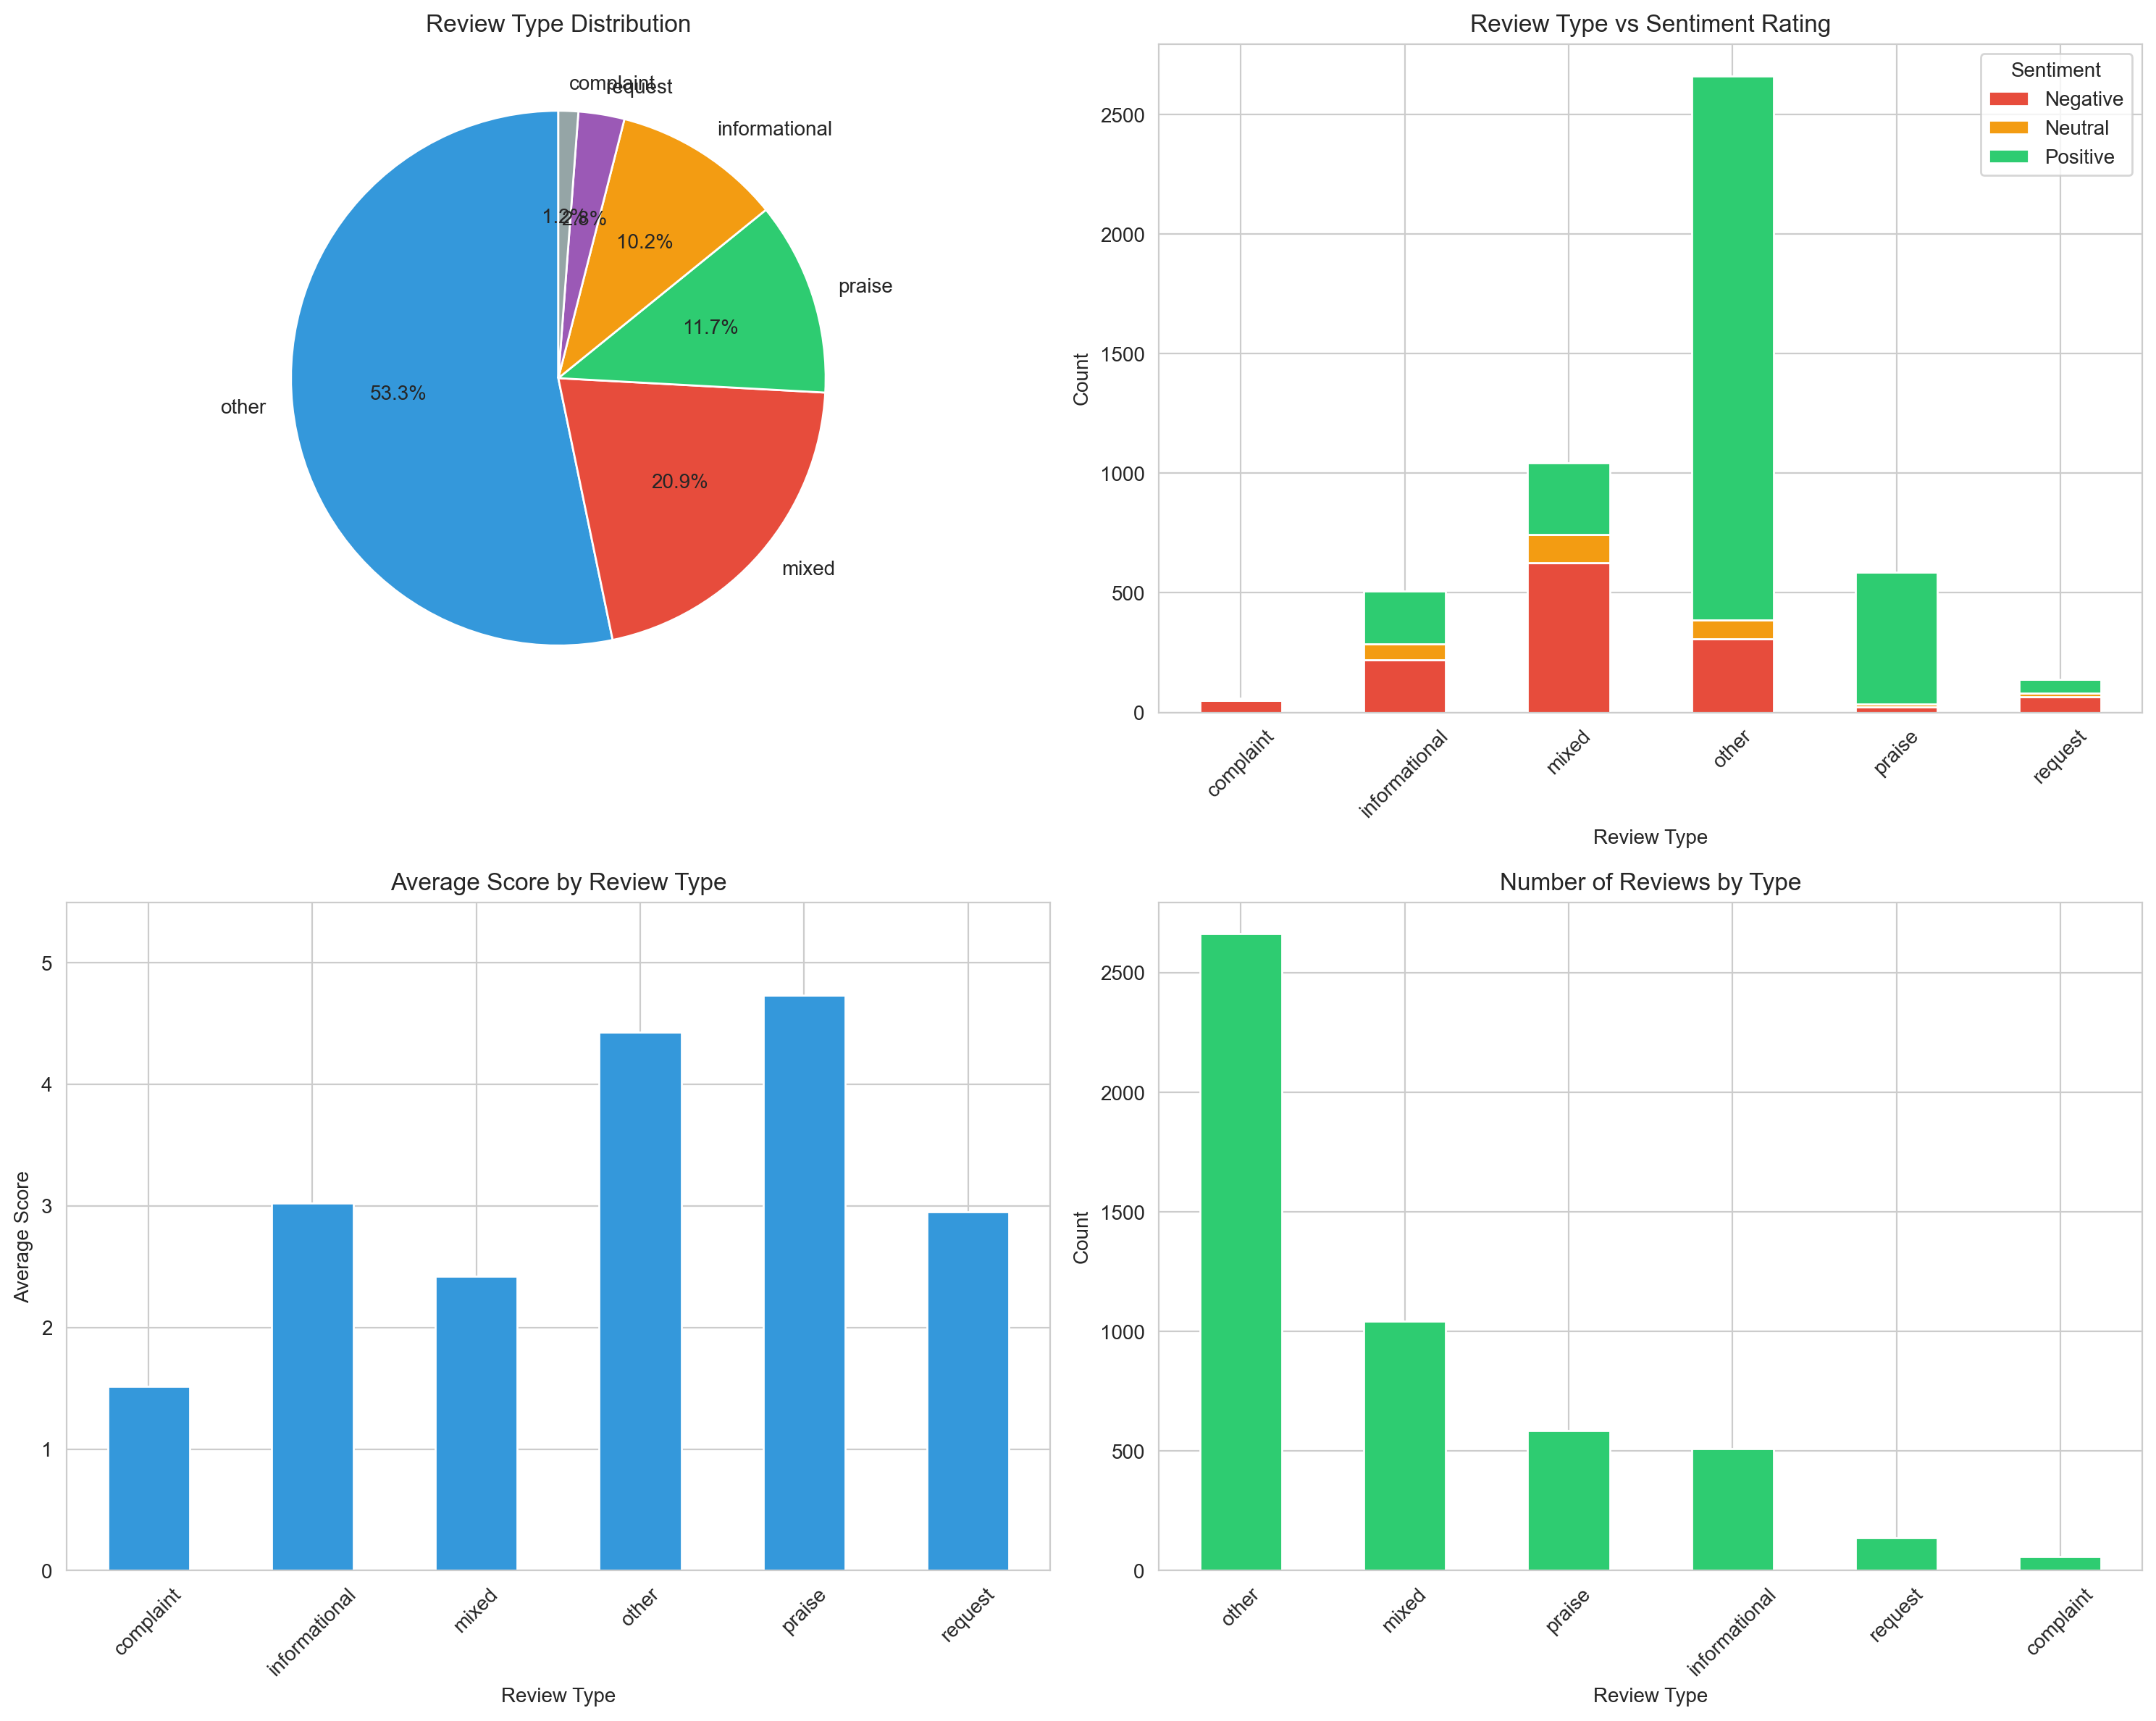


Sample Reviews from Each Type:

[MIXED] Score: 4⭐ | Sentiment: Positive
   terlalu sering minta di update...

[INFORMATIONAL] Score: 3⭐ | Sentiment: Neutral
   update teruss...capek deh...

[COMPLAINT] Score: 1⭐ | Sentiment: Negative
   aplikasi udh 2 hri error gada perbaikan...

[PRAISE] Score: 5⭐ | Sentiment: Positive
   belanja mudah, murah dan nyaman...

[OTHER] Score: 5⭐ | Sentiment: Positive
   belanja d superindo sangat memuaskan. harga nya murah terjangkau...

[REQUEST] Score: 4⭐ | Sentiment: Positive
   Hanya untuk tau informasi yg lagi diskon sama buat scan barcode aja...


In [45]:
# ============================================================================
# 5. REVIEW TYPE CATEGORIZATION (Kategorisasi Tipe Review)
# ============================================================================
print("\n" + "="*80)
print("5. REVIEW TYPE CATEGORIZATION (Kategorisasi Tipe Review)")
print("="*80)
print("Penjelasan: Kategorisasi review ke tipe spesifik berdasarkan pola regex")
print("            (Praise, Complaint, Request, Informational, Mixed)")

# Regex patterns untuk kategorisasi
review_type_patterns = {
    'praise': r'\b(bagus|bagus banget|luar biasa|excellent|amazing|terbaik|sempurna|suka|gampang|cepat|responsif|cepat banget|lancar|enak|nyaman)\b',
    'complaint': r'\b(jelek|kecewa|mengecewakan|buruk|rusak|error|bug|tidak bisa|gak bisa|lambat|lelet|tidak bagus|sampah)\b',
    'request': r'\b(mohon|tolong|harap|bisa|ditambah|fitur|bapak|ibu|seharusnya|sebaiknya|alangkah|minta|bikin|buat|tambahin)\b',
    'informational': r'\b(update|versi|baru|sudah|ada|belum|bisa|apa|kok|gimana|caranya|bagaimana)\b',
}

def categorize_review_type(text):
    """Kategorisasi tipe review berdasarkan pola"""
    if pd.isna(text):
        return 'unknown'
    
    text = str(text).lower()
    type_counts = {}
    
    for review_type, pattern in review_type_patterns.items():
        matches = re.findall(pattern, text, re.IGNORECASE)
        type_counts[review_type] = len(matches)
    
    # Tentukan tipe berdasarkan pattern yang paling banyak ditemukan
    if sum(type_counts.values()) == 0:
        return 'other'
    
    # Cek kombinasi untuk tipe mixed
    detected_types = [rt for rt, cnt in type_counts.items() if cnt > 0]
    
    if len(detected_types) > 1:
        return 'mixed'
    elif len(detected_types) == 1:
        return detected_types[0]
    else:
        return 'other'

# Terapkan kategorisasi
print("Mengkategorisasi tipe review...")
df_mysuperindo['review_type'] = df_mysuperindo['content'].apply(categorize_review_type)

# Statistik
print(f"\nReview Type Distribution:")
review_type_counts = df_mysuperindo['review_type'].value_counts()
for review_type, count in review_type_counts.items():
    pct = (count / len(df_mysuperindo)) * 100
    print(f"   {review_type:15s}: {count:5d} ({pct:5.1f}%)")

# Analisis Review Type vs Sentiment Rating
print(f"\nReview Type vs Sentiment Rating:")
review_type_sentiment = pd.crosstab(
    df_mysuperindo['review_type'], 
    df_mysuperindo['sentiment_rating'], 
    margins=True
)
print(review_type_sentiment)

# Analisis Review Type vs Score
print(f"\nAverage Score by Review Type:")
avg_score_by_type = df_mysuperindo.groupby('review_type')['score'].agg(['mean', 'count', 'std'])
print(avg_score_by_type)

# Visualisasi - Review Type Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Review Type Pie Chart
colors_pie = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']
axes[0, 0].pie(review_type_counts.values, labels=review_type_counts.index, autopct='%1.1f%%', 
               colors=colors_pie[:len(review_type_counts)], startangle=90)
axes[0, 0].set_title("Review Type Distribution")

# 2. Review Type vs Sentiment (Stacked Bar)
review_type_sentiment_no_margin = pd.crosstab(df_mysuperindo['review_type'], df_mysuperindo['sentiment_rating'])
review_type_sentiment_no_margin.plot(kind='bar', stacked=True, ax=axes[0, 1], 
                                     color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0, 1].set_title("Review Type vs Sentiment Rating")
axes[0, 1].set_xlabel("Review Type")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(title="Sentiment")
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# 3. Average Score by Review Type
avg_score_by_type['mean'].plot(kind='bar', ax=axes[1, 0], color='#3498db')
axes[1, 0].set_title("Average Score by Review Type")
axes[1, 0].set_xlabel("Review Type")
axes[1, 0].set_ylabel("Average Score")
axes[1, 0].set_ylim(0, 5.5)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# 4. Count of Reviews by Type
review_type_counts.plot(kind='bar', ax=axes[1, 1], color='#2ecc71')
axes[1, 1].set_title("Number of Reviews by Type")
axes[1, 1].set_xlabel("Review Type")
axes[1, 1].set_ylabel("Count")
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Sampel review dari setiap tipe
print("\nSample Reviews from Each Type:")
for review_type in df_mysuperindo['review_type'].unique():
    sample = df_mysuperindo[df_mysuperindo['review_type'] == review_type].iloc[0]
    print(f"\n[{review_type.upper()}] Score: {sample['score']}⭐ | Sentiment: {sample['sentiment_rating']}")
    print(f"   {sample['content'][:80]}...")
